In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
token = os.getenv('KAGGLE_API_TOKEN')

# Part 1: Data import and analysis
## a) Import data


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)


from kaggle.api.kaggle_api_extended import KaggleApi

# Load environment variables
load_dotenv()

# Authenticate with Kaggle using the token from .env
api = KaggleApi()
api.authenticate()

# Download the dataset with force option to re-download if corrupted
dataset_path = '/home/linux-mint-cb303/Desktop/UET/FootballPredictionsAFC/data'
api.dataset_download_files('martj42/international-football-results-from-1872-to-2017', path=dataset_path, unzip=True, force=True)

print(f"Dataset downloaded to: {dataset_path}")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Dataset URL: https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017
Dataset downloaded to: /home/linux-mint-cb303/Desktop/UET/FootballPredictionsAFC/data


In [3]:
from pathlib import Path
import re
import numpy as np
import pandas as pd


def team_name_to_slug(team_name: str) -> str:
    """Convert team names to slug format used by the country-year scraper output."""
    alias = {
        "China PR": "China",
        "Saudi Arabia": "Saudi_Arabia",
        "United Arab Emirates": "United_Arab_Emirates",
        "South Korea": "South_Korea",
        "North Korea": "North_Korea",
        "Hong Kong": "Hong_Kong",
        "Northern Mariana Islands": "Northern_Mariana_Islands",
        "Timor-Leste": "East_Timor",
    }
    if team_name in alias:
        return alias[team_name]
    return str(team_name).replace("-", "_").replace(" ", "_")


def parse_height_to_m(value):
    """Convert height like '1.77m' or '177 cm' to meters float."""
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if not text:
        return np.nan

    m_match = re.search(r"(\d+(?:\.\d+)?)\s*m", text)
    if m_match:
        return float(m_match.group(1))

    cm_match = re.search(r"(\d+(?:\.\d+)?)\s*cm", text)
    if cm_match:
        return float(cm_match.group(1)) / 100.0

    try:
        numeric = float(text)
        return numeric if numeric < 3 else numeric / 100.0
    except ValueError:
        return np.nan


candidate_paths = [
    Path("downloaded_files/scrape_exports/afc_country_year_data.csv"),
    Path("../downloaded_files/scrape_exports/afc_country_year_data.csv"),
]
country_year_stats_path = next((p for p in candidate_paths if p.exists()), None)
if country_year_stats_path is None:
    raise FileNotFoundError(
        "afc_country_year_data.csv not found. Run/export scraper notebook first."
    )

country_year_stats_df = pd.read_csv(country_year_stats_path)
country_year_stats_df["year"] = pd.to_numeric(country_year_stats_df["year"], errors="coerce").astype("Int64")
country_year_stats_df["team_slug"] = country_year_stats_df["country_slug"].astype(str)
country_year_stats_df["team_age"] = pd.to_numeric(country_year_stats_df["average_age"], errors="coerce")
country_year_stats_df["team_height"] = country_year_stats_df["average_height"].apply(parse_height_to_m)

country_year_profile_lookup = country_year_stats_df[["team_slug", "year", "team_age", "team_height"]].drop_duplicates(["team_slug", "year"])

print(f"Loaded country-year profile data: {len(country_year_profile_lookup)} rows from {country_year_stats_path}")

Loaded country-year profile data: 1504 rows from downloaded_files/scrape_exports/afc_country_year_data.csv


In [4]:
df = pd.read_csv(os.path.join(dataset_path, 'results.csv'))

df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49283,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49284,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49285,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  object 
 1   home_team   49287 non-null  object 
 2   away_team   49287 non-null  object 
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  object 
 6   city        49287 non-null  object 
 7   country     49287 non-null  object 
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


## b) Extract the matches between teams in the AFC Confederation

In [6]:
teams_in_asia = [
    "Afghanistan", "Australia", "Bahrain", "Bangladesh", "Bhutan", 
    "Brunei", "Cambodia", "China PR", "Taiwan", 
    "North Korea", "Guam", "Hong Kong", "India", "Indonesia", "Iran", 
    "Iraq", "Japan", "Jordan", "Kuwait", "Kyrgyzstan", "Laos", 
    "Lebanon", "Macau", "Malaysia", "Maldives", "Mongolia", "Myanmar", 
    "Nepal", "Northern Mariana Islands", "Oman", "Pakistan", "Palestine", 
    "Philippines", "Qatar", "Saudi Arabia", "Singapore", "South Korea", 
    "Sri Lanka", "Syria", "Tajikistan", "Thailand", "Timor-Leste", 
    "Turkmenistan", "United Arab Emirates", "Uzbekistan", "Vietnam", "Yemen"
]



In [7]:
# 1. Convert the date column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# 2. Define the filtering criteria
# We use .isin() to check if both teams are in your list
# and ensure the year is 1995 or greater
afc_matches_since_2000 = df[
    (df['home_team'].isin(teams_in_asia)) & 
    (df['away_team'].isin(teams_in_asia)) & 
    (df['date'].dt.year >= 1995)
]

afc_matches_since_2000

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
20155,1995-02-15,Australia,Japan,2.0,1.0,Friendly,Sydney,Australia,False
20161,1995-02-19,China PR,South Korea,0.0,0.0,Dynasty Cup,Victoria,Hong Kong,True
20162,1995-02-19,Hong Kong,Japan,0.0,3.0,Dynasty Cup,Victoria,Hong Kong,False
20163,1995-02-21,Hong Kong,China PR,0.0,0.0,Dynasty Cup,Victoria,Hong Kong,False
20164,1995-02-21,Japan,South Korea,1.0,1.0,Dynasty Cup,Victoria,Hong Kong,True
...,...,...,...,...,...,...,...,...,...
49008,2025-12-11,Palestine,Saudi Arabia,1.0,2.0,Arab Cup,Lusail,Qatar,True
49009,2025-12-12,Jordan,Iraq,1.0,0.0,Arab Cup,Al Rayyan,Qatar,True
49012,2025-12-15,Saudi Arabia,Jordan,0.0,1.0,Arab Cup,Al Khor,Qatar,True
49070,2026-01-26,Uzbekistan,China PR,2.0,2.0,Friendly,Dubai,United Arab Emirates,True


In [8]:
mask = (
    (afc_matches_since_2000['date'].dt.year >= 2025) &
    (afc_matches_since_2000['date'].dt.month <= 9) &
    (
        (afc_matches_since_2000['home_team'] == 'Malaysia') |
        (afc_matches_since_2000['away_team'] == 'Malaysia')
    )
)

afc_matches_since_2000.loc[mask, 'tournament'] = 'Forfeited'

afc_matches_since_2000[
    (df['date'].dt.year >= 2025) &
    (df['date'].dt.month <= 9) &
    ((afc_matches_since_2000['home_team'] == 'Malaysia') |
     (afc_matches_since_2000['away_team'] == 'Malaysia'))
]


/tmp/ipykernel_4928/268665084.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  afc_matches_since_2000[


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
48204,2025-03-25,Malaysia,Nepal,2.0,0.0,Forfeited,Johor,Malaysia,False
48381,2025-06-10,Malaysia,Vietnam,4.0,0.0,Forfeited,Kuala Lumpur,Malaysia,False
48485,2025-09-04,Malaysia,Singapore,2.0,1.0,Forfeited,Kuala Lumpur,Malaysia,False
48573,2025-09-08,Malaysia,Palestine,1.0,0.0,Forfeited,Johor,Malaysia,False


## c) Data analysis and visualization

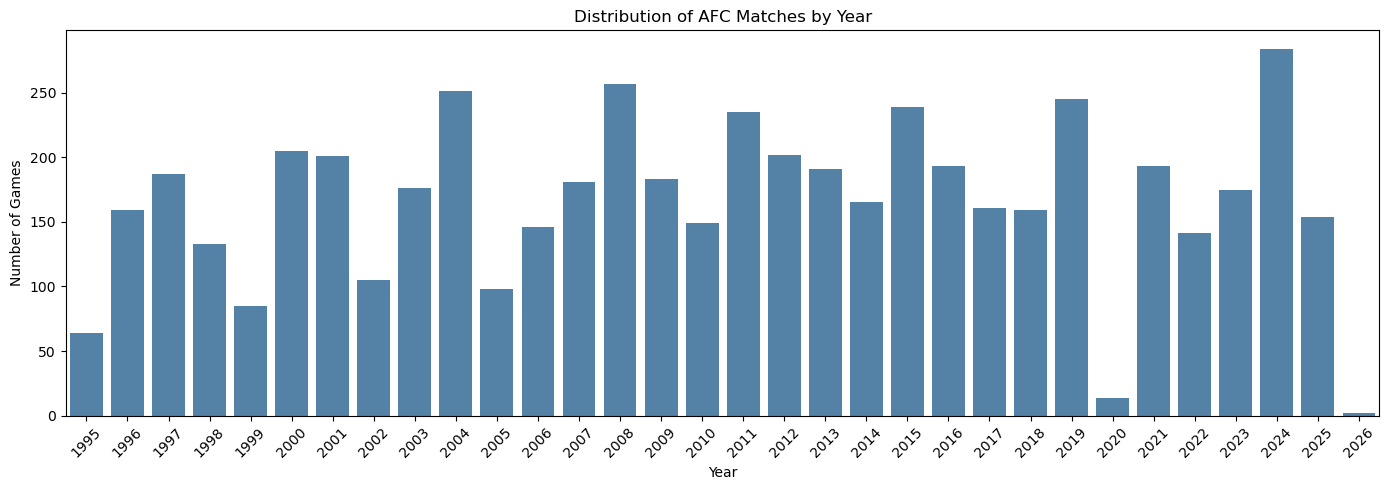

/tmp/ipykernel_4928/1072634083.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neutral_counts.index, y=neutral_counts.values, palette=['#2E86AB', '#F18F01'])


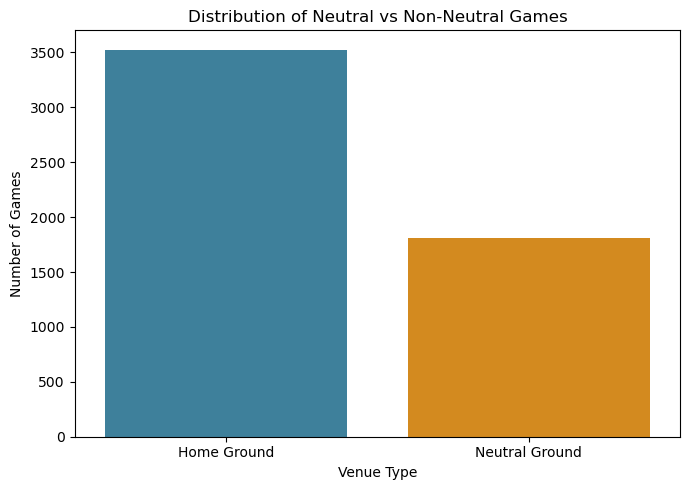

neutral
Home Ground       3525
Neutral Ground    1808
Name: count, dtype: int64

In [9]:
# Basic EDA: Distribution of matches by year, neutral vs non-neutral, scoreline distribution

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use whichever main match dataframe is already loaded in the notebook.
if 'afc_matches_since_2000' in globals():
    plot_df = afc_matches_since_2000.copy()
elif 'df' in globals():
    plot_df = df.copy()
else:
    raise NameError("No match dataframe found. Run the data-loading/preprocessing cells first.")

plot_df['date'] = pd.to_datetime(plot_df['date'], errors='coerce')

# 1) Distribution of games by year
matches_by_year = plot_df['date'].dt.year.value_counts().sort_index()

plt.figure(figsize=(14, 5))
sns.barplot(x=matches_by_year.index, y=matches_by_year.values, color='steelblue')
plt.title('Distribution of AFC Matches by Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2) Distribution of neutral-ground vs non-neutral games
neutral_counts = (
    plot_df['neutral']
    .map({True: 'Neutral Ground', False: 'Home Ground'})
    .value_counts()
    .reindex(['Home Ground', 'Neutral Ground'])
)

plt.figure(figsize=(7, 5))
sns.barplot(x=neutral_counts.index, y=neutral_counts.values, palette=['#2E86AB', '#F18F01'])
plt.title('Distribution of Neutral vs Non-Neutral Games')
plt.xlabel('Venue Type')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.show()

neutral_counts

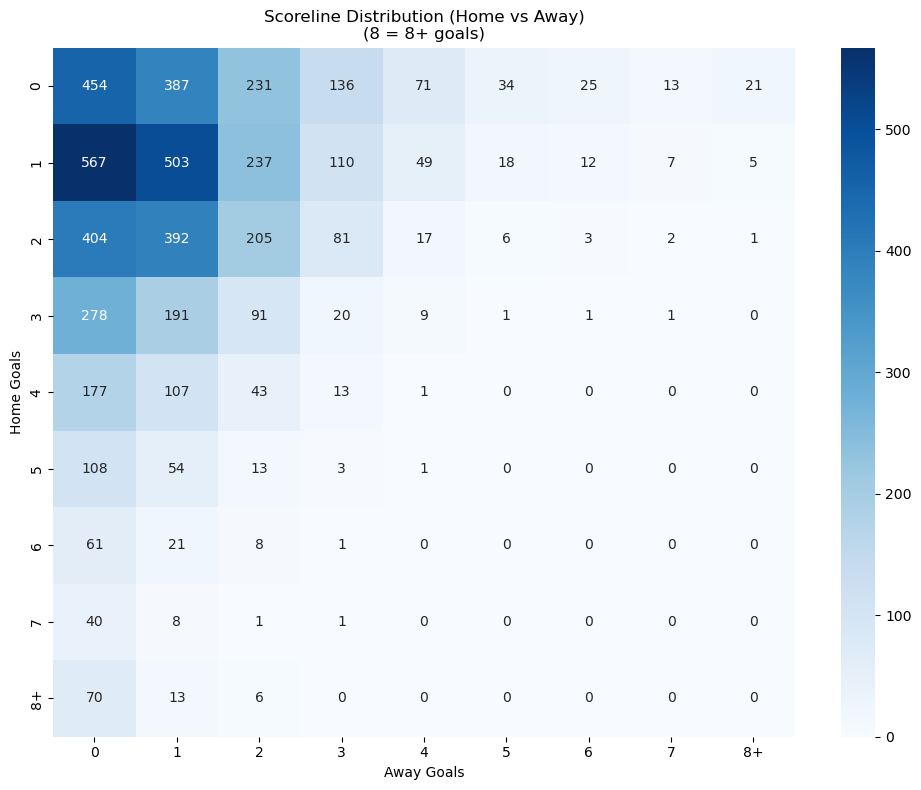

,0,1,2,3,4,5,6,7,8+
0,454,387,231,136,71,34,25,13,21
1,567,503,237,110,49,18,12,7,5
2,404,392,205,81,17,6,3,2,1
3,278,191,91,20,9,1,1,1,0
4,177,107,43,13,1,0,0,0,0
5,108,54,13,3,1,0,0,0,0
6,61,21,8,1,0,0,0,0,0
7,40,8,1,1,0,0,0,0,0
8+,70,13,6,0,0,0,0,0,0


In [10]:
# 3) Scoreline distribution (home vs away goals)

import matplotlib.pyplot as plt
import seaborn as sns
# Scoreline distribution grid (0-7, and 8+ bucket)
scoreline_grid = pd.crosstab(
    afc_matches_since_2000["home_score"].clip(upper=8),
    afc_matches_since_2000["away_score"].clip(upper=8)
).reindex(index=range(9), columns=range(9), fill_value=0)

# Rename 8 as "8+"
labels = [str(i) for i in range(8)] + ["8+"]
scoreline_grid.index = labels
scoreline_grid.columns = labels

plt.figure(figsize=(10, 8))
sns.heatmap(scoreline_grid, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Scoreline Distribution (Home vs Away)\n(8 = 8+ goals)")
plt.xlabel("Away Goals")
plt.ylabel("Home Goals")
plt.tight_layout()
plt.show()

scoreline_grid

In [11]:
# Create a table of Wins, Draws, Losses, and Win% for each team in Asia since 2000

stats_list = []

for team in teams_in_asia:
    # Filter matches where the team participated
    home = afc_matches_since_2000[afc_matches_since_2000['home_team'] == team]
    away = afc_matches_since_2000[afc_matches_since_2000['away_team'] == team]
    
    # Calculate Wins
    wins = (home['home_score'] > home['away_score']).sum() + \
           (away['away_score'] > away['home_score']).sum()
    
    # Calculate Losses
    losses = (home['home_score'] < home['away_score']).sum() + \
             (away['away_score'] < away['home_score']).sum()
    
    # Calculate Draws
    draws = (home['home_score'] == home['away_score']).sum() + \
            (away['away_score'] == away['home_score']).sum()
    
    played = wins + draws + losses
    
    # Calculate Win Percentage (Ratio)
    win_percentage = (wins / played * 100) if played > 0 else 0
    
    stats_list.append({
        'Team': team,
        'Played': played,
        'Wins': wins,
        'Draws': draws,
        'Losses': losses,
        'Win%': round(win_percentage, 2)
    })

# 4. Create and sort the final DataFrame
wdl_df = pd.DataFrame(stats_list).sort_values(by='Win%', ascending=False)

# Optional: Reset index for a clean table
wdl_df = wdl_df.reset_index(drop=True)

wdl_df

,Team,Played,Wins,Draws,Losses,Win%
0,Japan,247,163,46,38,65.99
1,Iran,295,187,71,37,63.39
2,Australia,163,97,35,31,59.51
3,South Korea,263,154,70,39,58.56
4,Saudi Arabia,345,197,77,71,57.10
5,Uzbekistan,279,142,54,83,50.90
6,Thailand,371,183,85,103,49.33
7,China PR,298,144,72,82,48.32
8,Qatar,345,164,85,96,47.54
9,Oman,360,170,92,98,47.22


In [12]:
# Look at the unique tournaments in the filtered matches
afc_matches_since_2000["tournament"].unique()

array(['Friendly', 'Dynasty Cup', "King's Cup", 'Nehru Cup', 'SAFF Cup',
       'Merdeka Tournament', 'Southeast Asian Games', 'South Asian Games',
       'AFC Asian Cup qualification',
       'United Arab Emirates Friendship Tournament', 'AFF Championship',
       'FIFA World Cup qualification', 'Gulf Cup', 'AFC Asian Cup',
       'Dunhill Cup', 'East Asian Games', 'Confederations Cup',
       'AFF Championship qualification', 'Arab Cup qualification',
       'Arab Cup', 'Asian Games', 'WAFF Championship', 'Millennium Cup',
       'Cup of Ancient Civilizations', "Prime Minister's Cup",
       'EAFF Championship', 'Kirin Cup', 'AFC Challenge Cup',
       'FIFA World Cup', 'AFC Challenge Cup qualification', 'VFF Cup',
       'Dragon Cup', 'Kirin Challenge Cup', 'Intercontinental Cup',
       'Three Nations Cup', 'Mahinda Rajapaksa Cup', 'Navruz Cup',
       'Jordan International Tournament', 'Tri Nation Tournament',
       'CAFA Nations Cup', 'FIFA Series', 'Marianas Cup',
       'ASEAN

In [13]:
# Define tournament weights based on importance

asian_world_quals = ['AFC Asian Cup qualification', 'FIFA World Cup qualification']
asian_world_finals = ['AFC Asian Cup', 'FIFA World Cup']
challenge_cup = ['AFC Challenge Cup', 'AFC Challenge Cup qualification']
regional_cups = ['WAFF Championship', 'AFF Championship', 'Gulf Cup', 'Arab Cup', 'SAFF Cup', 'EAFF Championship', 'East Asian Games', 'ASEAN Championship']
regional_cups_quals = ['AFF Championship qualification', 'Arab Cup qualification', 'ASEAN Championship qualification', 'EAFF Championship qualification']
def tournament_weight(tournament):
    if tournament in asian_world_quals:
        return 20
    elif tournament in asian_world_finals:
        return 25
    elif tournament in challenge_cup:
        return 15
    elif tournament in regional_cups:
        return 15
    elif tournament in regional_cups_quals:
        return 10
    elif tournament == 'Forfeited':
        return 1
    else:
        return 5

    

# Part 2: Data Engineering
## a) Glicko Rating handling

In [14]:
# Glicko-1 implementation with tournament weights and goal difference index, with a table to check for the final results

import math

# 1. Initialize Ratings and RD
# We use a dict of tuples: {team: (rating, RD)}
glicko_ratings = {team: (1500.0, 350.0) for team in teams_in_asia}

# Constants
q = math.log(10) / 400  # 0.0057565
c = 34.6                # Typical value for RD growth over time

def g(rd):
    """Calculates the 'g' factor based on opponent RD."""
    return 1 / math.sqrt(1 + 3 * (q**2) * (rd**2) / (math.pi**2))

def update_glicko(r1, rd1, r2, rd2, home_score, away_score, tournament):
    """
    r1, rd1: Current team
    r2, rd2: Opponent
    outcome: 1 for win, 0.5 for draw, 0 for loss
    """
    # 1. Standard Glicko constants
    q = math.log(10) / 400
    g_rd2 = 1 / math.sqrt(1 + 3 * (q**2) * (rd2**2) / (math.pi**2))
    expected = 1 / (1 + 10**(-g_rd2 * (r1 - r2) / 400))
    
    # 2. Determine Outcome (W)
    if home_score > away_score: outcome = 1
    elif home_score < away_score: outcome = 0
    else: outcome = 0.5
    
    # 3. Calculate Goal Difference Index (G) - From your provided formula
    n = abs(home_score - away_score)
    if n <= 1:
        g_index = 1
    elif n == 2:
        g_index = 1.5
    elif n == 3:
        g_index = 2
    elif n == 4:
        g_index = 2.25
    else:
        g_index = 1.75 + n / 8
        
    # 4. Get Tournament Weight (K)
    k = tournament_weight(tournament)
    
    # 5. Apply updates
    # We multiply the 'step' by (K/constant * G) 
    # Note: Standard Glicko doesn't use K, so we normalize K (usually 20 is standard)
    d_squared = 1 / (q**2 * g_rd2**2 * expected * (1 - expected))
    
    # New Rating calculation incorporating G and K
    # We use (K/20) as a multiplier to scale the Glicko update to match your tournament weights
    rating_change = (q / (1/rd1**2 + 1/d_squared)) * g_rd2 * (outcome - expected)
    new_r = r1 + (rating_change * g_index * (k/20))
    
    # New RD (Uncertainty usually decreases regardless of goal count)
    new_rd = math.sqrt(1 / (1/rd1**2 + 1/d_squared))
    
    return new_r, new_rd

# 2. Process matches
for index, row in afc_matches_since_2000.sort_values('date').iterrows():
    home, away = row['home_team'], row['away_team']
    
    r_h, rd_h = glicko_ratings[home]
    r_a, rd_a = glicko_ratings[away]
    
    # Update both (Note: In Glicko, we usually update RD for time passed too)
    new_rh, new_rdh = update_glicko(r_h, rd_h, r_a, rd_a, row['home_score'], row['away_score'], row['tournament'])
    new_ra, new_rda = update_glicko(r_a, rd_a, r_h, rd_h, row['away_score'], row['home_score'], row['tournament'])
    
    glicko_ratings[home] = (new_rh, new_rdh)
    glicko_ratings[away] = (new_ra, new_rda)

glicko_ratings

{'Afghanistan': (1244.3773938122833, 40.84428157991221),
 'Australia': (1929.6896078360999, 32.390671523083064),
 'Bahrain': (1700.366793146234, 20.107804801620055),
 'Bangladesh': (1204.03368249419, 30.06356287228488),
 'Bhutan': (832.9587311316527, 59.840175129350506),
 'Brunei': (926.4629363006391, 45.95328198154247),
 'Cambodia': (1040.484828249075, 36.18165885928229),
 'China PR': (1775.752024794563, 23.961558688915986),
 'Taiwan': (1118.8942528803643, 44.776589323865586),
 'North Korea': (1643.249262594461, 27.987766477063374),
 'Guam': (886.1901050759251, 65.82971352532657),
 'Hong Kong': (1397.9215624435747, 30.982183363168357),
 'India': (1406.0990816500755, 27.412833458101602),
 'Indonesia': (1513.8553664356216, 25.523988274057128),
 'Iran': (1940.732758569362, 25.54293389124142),
 'Iraq': (1757.55248342769, 20.55381256057439),
 'Japan': (1967.8538327782517, 27.390636255241635),
 'Jordan': (1731.65202701442, 21.561830135049753),
 'Kuwait': (1697.3739671812564, 20.952050257653

In [15]:
# Convert to DataFrame for better visualization and also sorting the teams by rating

glicko_df = pd.DataFrame.from_dict(glicko_ratings, orient='index', columns=['Rating', 'RD'])

glicko_df = glicko_df.reset_index().rename(columns={'index': 'Team'})


glicko_df['Lower_Bound'] = glicko_df['Rating'] - (2 * glicko_df['RD'])
glicko_df['Upper_Bound'] = glicko_df['Rating'] + (2 * glicko_df['RD'])

glicko_df = glicko_df.sort_values(by='Rating', ascending=False).reset_index(drop=True)

glicko_df = glicko_df.round(2)

glicko_df

,Team,Rating,RD,Lower_Bound,Upper_Bound
0,Japan,1967.85,27.39,1913.07,2022.64
1,Iran,1940.73,25.54,1889.65,1991.82
2,Australia,1929.69,32.39,1864.91,1994.47
3,South Korea,1919.38,25.15,1869.08,1969.67
4,Saudi Arabia,1849.73,23.38,1802.96,1896.50
5,Uzbekistan,1797.78,23.66,1750.46,1845.11
6,China PR,1775.75,23.96,1727.83,1823.68
7,Qatar,1766.96,21.06,1724.83,1809.08
8,Iraq,1757.55,20.55,1716.44,1798.66
9,Jordan,1731.65,21.56,1688.53,1774.78


In [16]:
# Use the above Glicko rating system to create a new dataframe that includes pre-match Glicko ratings for each team in each match
def get_pre_match_glicko(df, teams_list):
    """
    Creates a new dataframe with pre-match Glicko-1 scores for each team.
    Initial score: (1500.0, 350.0)
    """
    # Initialize ratings
    current_ratings = {team: (1500.0, 350.0) for team in teams_list}
    
    # Storage for the new data
    processed_data = []
    
    # Ensure chronological order
    df_sorted = df.sort_values('date').copy()
    
    for _, row in df_sorted.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        
        # Get pre-match ratings
        home_r, home_rd = current_ratings[home_team]
        away_r, away_rd = current_ratings[away_team]
        rating_diff = home_r - away_r
        
        # Store row data with pre-match ratings
        match_info = row.to_dict()
        match_info['home_glicko_rating'] = home_r
        match_info['home_glicko_rd'] = home_rd
        match_info['away_glicko_rating'] = away_r
        match_info['away_glicko_rd'] = away_rd
        match_info['glicko_rating_diff'] = rating_diff
        
        # We also need the ratings AFTER the game to facilitate the next step (form calculation)
        # However, the user wants this to be the draft dataframe for Glicko.
        
        # Update ratings after the match
        new_rh, new_rdh = update_glicko(home_r, home_rd, away_r, away_rd, 
                                        row['home_score'], row['away_score'], 
                                        row['tournament'])
        new_ra, new_rda = update_glicko(away_r, away_rd, home_r, home_rd, 
                                        row['away_score'], row['home_score'], 
                                        row['tournament'])
        
        match_info['home_glicko_rating_post'] = new_rh
        match_info['away_glicko_rating_post'] = new_ra
        
        processed_data.append(match_info)
        
        current_ratings[home_team] = (new_rh, new_rdh)
        current_ratings[away_team] = (new_ra, new_rda)
        
    return pd.DataFrame(processed_data)

# Create the processed dataframe (Draft for Step 2)
afc_matches_with_glicko = get_pre_match_glicko(afc_matches_since_2000, teams_in_asia)
afc_matches_with_glicko.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_glicko_rating,home_glicko_rd,away_glicko_rating,away_glicko_rd,glicko_rating_diff,home_glicko_rating_post,away_glicko_rating_post
0,1995-02-15,Australia,Japan,2.0,1.0,Friendly,Sydney,Australia,False,1500.000000,350.000000,1500.000000,350.000000,0.000000,1540.553001,1459.446999
1,1995-02-19,China PR,South Korea,0.0,0.0,Dynasty Cup,Victoria,Hong Kong,True,1500.000000,350.000000,1500.000000,350.000000,0.000000,1500.000000,1500.000000
2,1995-02-19,Hong Kong,Japan,0.0,3.0,Dynasty Cup,Victoria,Hong Kong,False,1500.000000,350.000000,1459.446999,290.230506,40.553001,1408.884766,1526.160774
3,1995-02-21,Hong Kong,China PR,0.0,0.0,Dynasty Cup,Victoria,Hong Kong,False,1408.884766,281.582486,1500.000000,290.230506,-91.115234,1414.840712,1493.646530
4,1995-02-21,Japan,South Korea,1.0,1.0,Dynasty Cup,Victoria,Hong Kong,True,1526.160774,253.529108,1500.000000,290.230506,26.160774,1524.698575,1501.945754


## b) Adding form and H2H features
Important features to see the current trajectory of the teams, including Win/Draw/Loss rates, Goals scored/conceeded, ELO of the wins/draws/losses, and H2H wins/draws/losses with goals scored/conceeded. For general form it's calculated for the last 10 matches, while for H2H it's calculated for the last 5 matches.

In [17]:
from collections import deque

def add_form_features(glicko_df, teams_list):
    """
    Takes the Glicko dataframe and adds last-10-games form features.
    """
    # Initialize history
    team_history = {team: deque(maxlen=10) for team in teams_list}

    # Storage for the new data
    processed_data = []

    # Crucial: glicko_df is already sorted by date from the previous step

    def calculate_streak(history):
        """
        Signed streak from most recent match backwards.
        Positive = undefeated streak (starts on a recent win).
        Negative = winless streak (starts on a recent draw/loss).
        """
        if not history:
            return 0

        recent = list(history)
        last = recent[-1]

        if last['W'] == 1:
            streak = 0
            for match in reversed(recent):
                if match['L'] == 0:
                    streak += 1
                else:
                    break
            return streak

        streak = 0
        for match in reversed(recent):
            if match['W'] == 0:
                streak += 1
            else:
                break
        return -streak

    def calculate_form(history):
        games_played = len(history)
        if not history:
            return 0, 0, 0, 0, 0, 1500.0, 0, 0, 0, 0, 0

        wins = sum(x['W'] for x in history)
        draws = sum(x['D'] for x in history)
        losses = sum(x['L'] for x in history)
        gf = sum(x['GF'] for x in history)
        ga = sum(x['GA'] for x in history)
        avg_opp_rating = sum(x['opp_post_rating'] for x in history) / games_played

        win_opp_ratings = [x['opp_post_rating'] for x in history if x['W'] == 1]
        draw_opp_ratings = [x['opp_post_rating'] for x in history if x['D'] == 1]
        loss_opp_ratings = [x['opp_post_rating'] for x in history if x['L'] == 1]

        avg_opp_rating_w = sum(win_opp_ratings) / len(win_opp_ratings) if win_opp_ratings else 0
        avg_opp_rating_d = sum(draw_opp_ratings) / len(draw_opp_ratings) if draw_opp_ratings else 0
        avg_opp_rating_l = sum(loss_opp_ratings) / len(loss_opp_ratings) if loss_opp_ratings else 0

        # Calculate ratios as requested (if games_played > 0)
        # All stats divided by games_played
        w_ratio = wins / games_played
        d_ratio = draws / games_played
        l_ratio = losses / games_played
        gf_ratio = gf / games_played
        ga_ratio = ga / games_played
        form_streak = calculate_streak(history)

        return (
            w_ratio,
            d_ratio,
            l_ratio,
            gf_ratio,
            ga_ratio,
            avg_opp_rating,
            games_played,
            avg_opp_rating_w,
            avg_opp_rating_d,
            avg_opp_rating_l,
            form_streak,
        )

    for _, row in glicko_df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']

        # 1. Get pre-match form stats
        (
            h_w,
            h_d,
            h_l,
            h_gf,
            h_ga,
            h_avg_opp,
            h_games,
            h_avg_opp_w,
            h_avg_opp_d,
            h_avg_opp_l,
            h_streak,
        ) = calculate_form(team_history[home_team])
        (
            a_w,
            a_d,
            a_l,
            a_gf,
            a_ga,
            a_avg_opp,
            a_games,
            a_avg_opp_w,
            a_avg_opp_d,
            a_avg_opp_l,
            a_streak,
        ) = calculate_form(team_history[away_team])

        # Store row data with form stats
        match_info = row.to_dict()
        match_info['home_form_W'] = h_w
        match_info['home_form_D'] = h_d
        match_info['home_form_L'] = h_l
        match_info['home_form_GF'] = h_gf
        match_info['home_form_GA'] = h_ga
        match_info['home_form_avg_opp_rating'] = h_avg_opp
        match_info['home_form_games_max10'] = h_games
        match_info['home_form_avg_opp_rating_W'] = h_avg_opp_w
        match_info['home_form_avg_opp_rating_D'] = h_avg_opp_d
        match_info['home_form_avg_opp_rating_L'] = h_avg_opp_l
        match_info['home_form_streak'] = h_streak

        match_info['away_form_W'] = a_w
        match_info['away_form_D'] = a_d
        match_info['away_form_L'] = a_l
        match_info['away_form_GF'] = a_gf
        match_info['away_form_GA'] = a_ga
        match_info['away_form_avg_opp_rating'] = a_avg_opp
        match_info['away_form_games_max10'] = a_games
        match_info['away_form_avg_opp_rating_W'] = a_avg_opp_w
        match_info['away_form_avg_opp_rating_D'] = a_avg_opp_d
        match_info['away_form_avg_opp_rating_L'] = a_avg_opp_l
        match_info['away_form_streak'] = a_streak

        processed_data.append(match_info)

        # 2. Update team history for the next matches
        h_score = row['home_score']
        a_score = row['away_score']

        if h_score > a_score:
            h_res = 'W'
        elif h_score < a_score:
            h_res = 'L'
        else:
            h_res = 'D'

        # Use post-match ratings as requested
        team_history[home_team].append({
            'W': 1 if h_res == 'W' else 0,
            'D': 1 if h_res == 'D' else 0,
            'L': 1 if h_res == 'L' else 0,
            'GF': h_score,
            'GA': a_score,
            'opp_post_rating': row['away_glicko_rating_post']
        })

        team_history[away_team].append({
            'W': 1 if h_res == 'L' else 0,
            'D': 1 if h_res == 'D' else 0,
            'L': 1 if h_res == 'W' else 0,
            'GF': a_score,
            'GA': h_score,
            'opp_post_rating': row['home_glicko_rating_post']
        })

    return pd.DataFrame(processed_data)

# Create the final processed dataframe with form features
afc_matches_with_features = add_form_features(afc_matches_with_glicko, teams_in_asia)
afc_matches_with_features

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_glicko_rating,...,away_form_D,away_form_L,away_form_GF,away_form_GA,away_form_avg_opp_rating,away_form_games_max10,away_form_avg_opp_rating_W,away_form_avg_opp_rating_D,away_form_avg_opp_rating_L,away_form_streak
0,1995-02-15,Australia,Japan,2.0,1.0,Friendly,Sydney,Australia,False,1500.000000,...,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0
1,1995-02-19,China PR,South Korea,0.0,0.0,Dynasty Cup,Victoria,Hong Kong,True,1500.000000,...,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0
2,1995-02-19,Hong Kong,Japan,0.0,3.0,Dynasty Cup,Victoria,Hong Kong,False,1500.000000,...,0.0,1.0,1.0,2.0,1540.553001,1,0.000000,0.000000,1540.553001,-1
3,1995-02-21,Hong Kong,China PR,0.0,0.0,Dynasty Cup,Victoria,Hong Kong,False,1408.884766,...,1.0,0.0,0.0,0.0,1500.000000,1,0.000000,1500.000000,0.000000,-1
4,1995-02-21,Japan,South Korea,1.0,1.0,Dynasty Cup,Victoria,Hong Kong,True,1526.160774,...,1.0,0.0,0.0,0.0,1500.000000,1,0.000000,1500.000000,0.000000,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5328,2025-12-11,Palestine,Saudi Arabia,1.0,2.0,Arab Cup,Lusail,Qatar,True,1532.544194,...,0.2,0.2,1.5,0.8,1757.683177,10,1699.639333,1863.157893,1826.339991,3
5329,2025-12-12,Jordan,Iraq,1.0,0.0,Arab Cup,Al Rayyan,Qatar,True,1729.227706,...,0.2,0.2,1.1,0.8,1670.296813,10,1615.069466,1787.086019,1719.189647,8
5330,2025-12-15,Saudi Arabia,Jordan,0.0,1.0,Arab Cup,Al Khor,Qatar,True,1851.298938,...,0.3,0.2,1.4,0.8,1738.188427,10,1683.159596,1786.789097,1802.859501,3
5331,2026-01-26,Uzbekistan,China PR,2.0,2.0,Friendly,Dubai,United Arab Emirates,True,1797.809487,...,0.0,0.7,0.7,2.0,1791.121759,10,1637.691194,0.000000,1856.877715,1


In [18]:
from collections import defaultdict, deque

def add_h2h_features(df):
    """
    Takes the dataframe with form features and computes the Head-2-Head 
    form for the last 5 matches strictly between the two playing teams. 
    """
    # Dictionary of deques: key is sorted tuple of (team1, team2)
    h2h_history = defaultdict(lambda: deque(maxlen=5))
    
    processed_data = []
    
    for _, row in df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        
        # Unique key for this particular matchup regardless of who is home or away
        pair_key = tuple(sorted([home_team, away_team]))
        history = h2h_history[pair_key]
        
        # Calculate pre-match stats
        h2h_games_max5 = len(history)
        h2h_home_win = 0
        h2h_away_win = 0
        h2h_draw = 0
        h2h_home_goals = 0
        h2h_away_goals = 0
        
        for past_match in history:
            if past_match['winner'] == home_team:
                h2h_home_win += 1
            elif past_match['winner'] == away_team:
                h2h_away_win += 1
            else:
                h2h_draw += 1
            
            # Identify which score belongs to which current team
            if past_match['home'] == home_team:
                h2h_home_goals += past_match['h_score']
                h2h_away_goals += past_match['a_score']
            else:
                h2h_home_goals += past_match['a_score']
                h2h_away_goals += past_match['h_score']
                
        # Store in dict
        match_info = row.to_dict()
        
        # Calculate ratios as requested (if h2h_games_max5 > 0)
        # All stats divided by h2h_games_max5
        match_info['H2H_home_team_win'] = h2h_home_win / h2h_games_max5 if h2h_games_max5 > 0 else 0
        match_info['H2H_draw'] = h2h_draw / h2h_games_max5 if h2h_games_max5 > 0 else 0
        match_info['H2H_away_team_win'] = h2h_away_win / h2h_games_max5 if h2h_games_max5 > 0 else 0
        
        match_info['H2H_games_max5'] = h2h_games_max5
        match_info['H2H_home_team_score_avg'] = h2h_home_goals / h2h_games_max5 if h2h_games_max5 > 0 else 0
        match_info['H2H_away_team_score_avg'] = h2h_away_goals / h2h_games_max5 if h2h_games_max5 > 0 else 0
        
        processed_data.append(match_info)
        
        # Update history for next matches
        h_score = row['home_score']
        a_score = row['away_score']
        
        if h_score > a_score:
            winner = home_team
        elif h_score < a_score:
            winner = away_team
        else:
            winner = 'Draw'
            
        h2h_history[pair_key].append({
            'winner': winner,
            'home': home_team,
            'away': away_team,
            'h_score': h_score,
            'a_score': a_score
        })
        
    return pd.DataFrame(processed_data)

# Create the dataframe containing all previously generated features + new H2H features
afc_matches_with_h2h = add_h2h_features(afc_matches_with_features)
with pd.option_context('display.max_columns', None):
    display(afc_matches_with_h2h)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_glicko_rating,home_glicko_rd,away_glicko_rating,away_glicko_rd,glicko_rating_diff,home_glicko_rating_post,away_glicko_rating_post,home_form_W,home_form_D,home_form_L,home_form_GF,home_form_GA,home_form_avg_opp_rating,home_form_games_max10,home_form_avg_opp_rating_W,home_form_avg_opp_rating_D,home_form_avg_opp_rating_L,home_form_streak,away_form_W,away_form_D,away_form_L,away_form_GF,away_form_GA,away_form_avg_opp_rating,away_form_games_max10,away_form_avg_opp_rating_W,away_form_avg_opp_rating_D,away_form_avg_opp_rating_L,away_form_streak,H2H_home_team_win,H2H_draw,H2H_away_team_win,H2H_games_max5,H2H_home_team_score_avg,H2H_away_team_score_avg
0,1995-02-15,Australia,Japan,2.0,1.0,Friendly,Sydney,Australia,False,1500.000000,350.000000,1500.000000,350.000000,0.000000,1540.553001,1459.446999,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0,0.0,0.0
1,1995-02-19,China PR,South Korea,0.0,0.0,Dynasty Cup,Victoria,Hong Kong,True,1500.000000,350.000000,1500.000000,350.000000,0.000000,1500.000000,1500.000000,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0,0.0,0.0
2,1995-02-19,Hong Kong,Japan,0.0,3.0,Dynasty Cup,Victoria,Hong Kong,False,1500.000000,350.000000,1459.446999,290.230506,40.553001,1408.884766,1526.160774,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,1.0,1.0,2.0,1540.553001,1,0.000000,0.000000,1540.553001,-1,0.0,0.0,0.0,0,0.0,0.0
3,1995-02-21,Hong Kong,China PR,0.0,0.0,Dynasty Cup,Victoria,Hong Kong,False,1408.884766,281.582486,1500.000000,290.230506,-91.115234,1414.840712,1493.646530,0.0,0.0,1.0,0.0,3.0,1526.160774,1,0.000000,0.000000,1526.160774,-1,0.0,1.0,0.0,0.0,0.0,1500.000000,1,0.000000,1500.000000,0.000000,-1,0.0,0.0,0.0,0,0.0,0.0
4,1995-02-21,Japan,South Korea,1.0,1.0,Dynasty Cup,Victoria,Hong Kong,True,1526.160774,253.529108,1500.000000,290.230506,26.160774,1524.698575,1501.945754,0.5,0.0,0.5,2.0,1.0,1474.718883,2,1408.884766,0.000000,1540.553001,1,0.0,1.0,0.0,0.0,0.0,1500.000000,1,0.000000,1500.000000,0.000000,-1,0.0,0.0,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5328,2025-12-11,Palestine,Saudi Arabia,1.0,2.0,Arab Cup,Lusail,Qatar,True,1532.544194,31.265395,1850.971180,23.457102,-318.426986,1531.963600,1851.298938,0.3,0.4,0.3,1.0,1.0,1711.542385,10,1741.537532,1745.471758,1636.308073,-1,0.6,0.2,0.2,1.5,0.8,1757.683177,10,1699.639333,1863.157893,1826.339991,3,0.0,0.8,0.2,5,0.2,1.2
5329,2025-12-12,Jordan,Iraq,1.0,0.0,Arab Cup,Al Rayyan,Qatar,True,1729.227706,21.639996,1758.538686,20.589450,-29.310980,1730.316980,1757.552483,0.4,0.4,0.2,1.4,0.9,1732.963813,10,1664.561374,1766.418407,1802.859501,2,0.6,0.2,0.2,1.1,0.8,1670.296813,10,1615.069466,1787.086019,1719.189647,8,0.2,0.4,0.4,5,0.6,0.8
5330,2025-12-15,Saudi Arabia,Jordan,0.0,1.0,Arab Cup,Al Khor,Qatar,True,1851.298938,23.431807,1730.316980,21.598613,120.981959,1849.727798,1731.652027,0.6,0.2,0.2,1.4,0.8,1735.100601,10,1662.001706,1863.157893,1826.339991,4,0.5,0.3,0.2,1.4,0.8,1738.188427,10,1683.159596,1786.789097,1802.859501,3,0.4,0.0,0.6,5,1.0,1.2
5331,2026-01-26,Uzbekistan,China PR,2.0,2.0,Friendly,Dubai,United Arab Emirates,True,1797.809487,23.716921,1775.725948,24.018197,22.083540,1797.784061,1775.752025,0.5,0.4,0.1,1.2,0.5,1739.795078,10,1658.328112,1832.801830,1775.102900,-1,0.3,0.0,0.7,0.7,2.0,1791.121759,10,1637.691194,0.000000,1856.877715,1,0.6,0.0,0.4,5,1.4,1.0


## c) Adding misc features
Adding features like the team's height difference, scoring potential by the home and away teams, and  other stats like match results (which is important for later classification) and tournament weight

In [19]:
def add_misc_features(df):
    """
    Adds miscellaneous features such as:
    - Tournament weighting
    - Match result label
    - Team profile features by match year
      (home_team_age, home_team_height, away_team_age, away_team_height)
    - Additional engineered matchup features
      (glicko_rd_sum, height_difference, home_score_potential, away_score_potential)
    """
    df = df.copy()
    
    # Existing misc features
    df['tournament_weight'] = df['tournament'].apply(tournament_weight)
    df['result'] = df.apply(
        lambda row: 'Home Win' if row['home_score'] > row['away_score'] else ('Away Win' if row['home_score'] < row['away_score'] else 'Draw'),
        axis=1,
    )

    # Add team profile features from the scraper CSV loaded in Cell 3
    if 'country_year_profile_lookup' not in globals():
        raise ValueError("country_year_profile_lookup is missing. Run Cell 3 first.")

    df['match_year'] = pd.to_datetime(df['date'], errors='coerce').dt.year.astype('Int64')
    df['home_team_slug'] = df['home_team'].astype(str).apply(team_name_to_slug)
    df['away_team_slug'] = df['away_team'].astype(str).apply(team_name_to_slug)

    home_lookup = country_year_profile_lookup.rename(columns={
        'team_slug': 'home_team_slug',
        'team_age': 'home_team_age',
        'team_height': 'home_team_height',
    })
    away_lookup = country_year_profile_lookup.rename(columns={
        'team_slug': 'away_team_slug',
        'team_age': 'away_team_age',
        'team_height': 'away_team_height',
    })

    df = df.merge(
        home_lookup,
        left_on=['home_team_slug', 'match_year'],
        right_on=['home_team_slug', 'year'],
        how='left',
    ).drop(columns=['year'], errors='ignore')

    df = df.merge(
        away_lookup,
        left_on=['away_team_slug', 'match_year'],
        right_on=['away_team_slug', 'year'],
        how='left',
    ).drop(columns=['year'], errors='ignore')

    # Additional engineered features requested
    df['glicko_rd_sum'] = df['home_glicko_rd'] + df['away_glicko_rd']
    df['height_difference'] = df['home_team_height'] - df['away_team_height']
    df['home_score_potential'] = df['home_form_GF'] + df['away_form_GA']
    df['away_score_potential'] = df['away_form_GF'] + df['home_form_GA']

    df = df.drop(columns=['match_year', 'home_team_slug', 'away_team_slug'], errors='ignore')
    return df

afc_matches_final = add_misc_features(afc_matches_with_h2h)
afc_matches_final[
    [
        'date',
        'home_team',
        'away_team',
        'home_team_age',
        'home_team_height',
        'away_team_age',
        'away_team_height',
        'glicko_rd_sum',
        'height_difference',
        'home_score_potential',
        'away_score_potential',
    ]
] .head()

,date,home_team,away_team,home_team_age,home_team_height,away_team_age,away_team_height,glicko_rd_sum,height_difference,home_score_potential,away_score_potential
0,1995-02-15,Australia,Japan,24.7,1.84,25.6,1.77,700.000000,0.07,0.0,0.0
1,1995-02-19,China PR,South Korea,22.9,1.80,23.9,1.80,700.000000,0.00,0.0,0.0
2,1995-02-19,Hong Kong,Japan,0.0,0.00,25.6,1.77,640.230506,-1.77,2.0,1.0
3,1995-02-21,Hong Kong,China PR,0.0,0.00,22.9,1.80,571.812992,-1.80,0.0,3.0
4,1995-02-21,Japan,South Korea,25.6,1.77,23.9,1.80,543.759614,-0.03,2.0,1.0


In [20]:
# Re-syncing the dataframe index to ensure masks align perfectly
afc_matches_final = afc_matches_final.reset_index(drop=True)

# Define columns to exclude
exclude_cols = [
    'date', 'home_team', 'away_team', 'home_score', 'away_score', 
    'tournament', 'city', 'country', 'result', 
    'home_glicko_rating_post', 'away_glicko_rating_post',
    'away_form_games_max10', 'home_form_games_max10', 'H2H_games_max5',
    'home_glicko_rd', 'away_glicko_rd', 
    'home_form_GF', 'home_form_GA', 'away_form_GF', 'away_form_GA', 
    'home_team_age', 'away_team_age',
    'home_form_streak', 'away_form_streak'
]

# Identify features
features = [col for col in afc_matches_final.columns if col not in exclude_cols]

# Create fresh masks aligned with the reset index
train_mask = (afc_matches_final['date'].dt.year >= 1996) & (afc_matches_final['date'].dt.year <= 2019)
val_mask = (afc_matches_final['date'].dt.year >= 2020) & (afc_matches_final['date'].dt.year <= 2022)
test_mask = (afc_matches_final['date'].dt.year >= 2023) & (afc_matches_final['date'].dt.year <= 2026)

# Split the data
X_train, y_train = afc_matches_final.loc[train_mask, features], afc_matches_final.loc[train_mask, 'result']
X_val, y_val = afc_matches_final.loc[val_mask, features], afc_matches_final.loc[val_mask, 'result']
X_test, y_test = afc_matches_final.loc[test_mask, features], afc_matches_final.loc[test_mask, 'result']

print(f"Data resynced. Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print(f"Features count: {len(features)}")

Data resynced. Train: 4306, Val: 348, Test: 615
Features count: 30


# Part 3. Initialize and run the ML model
## a) Running a simple XGBoost model to look for what features are the most important

In [21]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss, classification_report, accuracy_score
import pandas as pd
import numpy as np

# 1. Encode targets
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

print(f"Classes found: {list(le.classes_)}")

# 2. Convert to DMatrix (optional but recommended for performance)
# Alternatively, use the Scikit-learn wrapper
model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    device='cpu' # specify 'cuda' if using GPU
)

# 3. Train the model with early stopping
model.fit(
    X_train, y_train_enc,
    eval_set=[(X_val, y_val_enc)],
    verbose=100
)

# 4. Predict probabilities on the Test set
test_probs = model.predict_proba(X_test)
test_preds = le.inverse_transform(model.predict(X_test))

# 5. Add probabilities back to a result dataframe for visualization
results_info = afc_matches_final.loc[test_mask, ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'result']].copy()

for i, class_name in enumerate(le.classes_):
    results_info[f'prob_{class_name}'] = test_probs[:, i]

results_info['predicted_result'] = test_preds

print("\nModel Evaluation (Test Set):")
print(f"Accuracy: {accuracy_score(y_test_enc, model.predict(X_test)):.4f}")
print(f"Log Loss: {log_loss(y_test_enc, test_probs):.4f}")

# Display first few predictions with probabilities
results_info[['date', 'home_team', 'away_team', 'result', 'predicted_result', 'prob_Home Win', 'prob_Draw', 'prob_Away Win']]

Classes found: ['Away Win', 'Draw', 'Home Win']
[0]	validation_0-mlogloss:0.97819
[100]	validation_0-mlogloss:0.75297
[148]	validation_0-mlogloss:0.75876

Model Evaluation (Test Set):
Accuracy: 0.6098
Log Loss: 0.8510


,date,home_team,away_team,result,predicted_result,prob_Home Win,prob_Draw,prob_Away Win
4718,2023-01-02,Thailand,Cambodia,Home Win,Home Win,0.956354,0.029825,0.013821
4719,2023-01-02,Philippines,Indonesia,Away Win,Away Win,0.303366,0.303021,0.393613
4720,2023-01-03,Vietnam,Myanmar,Home Win,Home Win,0.826547,0.125171,0.048282
4721,2023-01-03,Malaysia,Singapore,Home Win,Home Win,0.527652,0.309951,0.162397
4722,2023-01-06,Indonesia,Vietnam,Draw,Draw,0.347256,0.385267,0.267477
...,...,...,...,...,...,...,...,...
5328,2025-12-11,Palestine,Saudi Arabia,Away Win,Away Win,0.116307,0.297702,0.585991
5329,2025-12-12,Jordan,Iraq,Home Win,Away Win,0.307904,0.345571,0.346525
5330,2025-12-15,Saudi Arabia,Jordan,Away Win,Home Win,0.429429,0.385694,0.184877
5331,2026-01-26,Uzbekistan,China PR,Draw,Home Win,0.507747,0.336101,0.156152


In [22]:
# Filter afc_matches_final for ASEAN Championship in 2024
asean_2024_matches = afc_matches_final[
    (afc_matches_final['tournament'] == 'ASEAN Championship') & 
    (afc_matches_final['date'].dt.year >= 2024)
].index

# Filter results_info (which already contains predictions) using those indices
asean_2024_predictions = results_info.loc[results_info.index.intersection(asean_2024_matches)]

# Display columns including probabilities and the final scores
display_cols = ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'result', 'predicted_result', 'prob_Home Win', 'prob_Draw', 'prob_Away Win']
asean_2024_predictions[display_cols].sort_values('date')

,date,home_team,away_team,home_score,away_score,result,predicted_result,prob_Home Win,prob_Draw,prob_Away Win
5134,2024-12-08,Cambodia,Malaysia,2.0,2.0,Draw,Away Win,0.092843,0.108551,0.798606
5135,2024-12-08,Timor-Leste,Thailand,0.0,10.0,Away Win,Away Win,0.030928,0.048594,0.920478
5137,2024-12-09,Myanmar,Indonesia,0.0,1.0,Away Win,Away Win,0.177413,0.254313,0.568275
5138,2024-12-09,Laos,Vietnam,1.0,4.0,Away Win,Away Win,0.080925,0.077477,0.841598
5140,2024-12-11,Singapore,Cambodia,2.0,1.0,Home Win,Home Win,0.729868,0.213144,0.056987
5141,2024-12-11,Malaysia,Timor-Leste,3.0,2.0,Home Win,Home Win,0.969312,0.021227,0.009461
5142,2024-12-12,Indonesia,Laos,3.0,3.0,Draw,Home Win,0.929675,0.052385,0.017940
5143,2024-12-12,Philippines,Myanmar,1.0,1.0,Draw,Home Win,0.649013,0.167288,0.183700
5144,2024-12-14,Timor-Leste,Singapore,0.0,3.0,Away Win,Away Win,0.098448,0.068357,0.833195
5145,2024-12-14,Thailand,Malaysia,1.0,0.0,Home Win,Home Win,0.563468,0.303773,0.132760


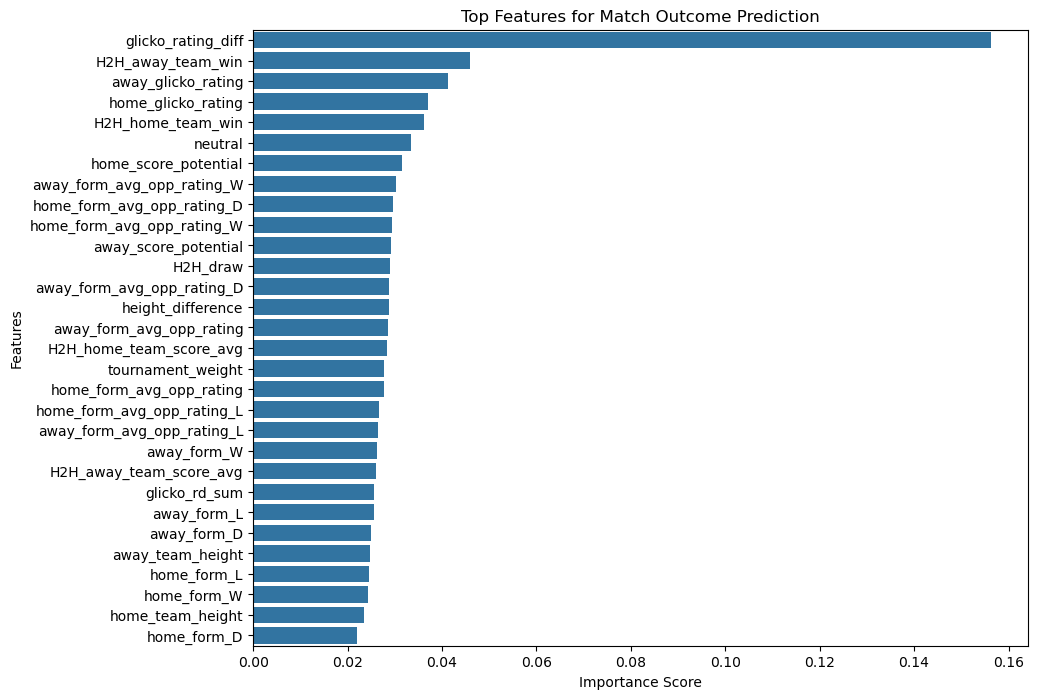

                       Feature  Importance
3           glicko_rating_diff    0.156345
20           H2H_away_team_win    0.045869
2           away_glicko_rating    0.041308
1           home_glicko_rating    0.036969
18           H2H_home_team_win    0.036293
0                      neutral    0.033430
28        home_score_potential    0.031551
15  away_form_avg_opp_rating_W    0.030242
9   home_form_avg_opp_rating_D    0.029594
8   home_form_avg_opp_rating_W    0.029458
29        away_score_potential    0.029169
19                    H2H_draw    0.028991
16  away_form_avg_opp_rating_D    0.028804
27           height_difference    0.028754
14    away_form_avg_opp_rating    0.028603
21     H2H_home_team_score_avg    0.028452
23           tournament_weight    0.027815
7     home_form_avg_opp_rating    0.027809
10  home_form_avg_opp_rating_L    0.026587
17  away_form_avg_opp_rating_L    0.026498
11                 away_form_W    0.026303
22     H2H_away_team_score_avg    0.025998
26         

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance from XGBoost model
feature_importance = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top Features for Match Outcome Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Display the numerical values
print(importance_df)

## b) Use Poisson + Dixon-Coles adjustment to help predict football expected goals and the final winner

In [24]:
from scipy.stats import poisson

# 1. Prepare target variables (Home and Away scores)
y_train_home = afc_matches_final.loc[train_mask, 'home_score']
y_train_away = afc_matches_final.loc[train_mask, 'away_score']

y_val_home = afc_matches_final.loc[val_mask, 'home_score']
y_val_away = afc_matches_final.loc[val_mask, 'away_score']

y_test_home = afc_matches_final.loc[test_mask, 'home_score']
y_test_away = afc_matches_final.loc[test_mask, 'away_score']

# 2. Define and train XGBoost Poisson models
params = {
    'objective': 'count:poisson',
    'eval_metric': 'poisson-nloglik',
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'early_stopping_rounds': 50,
    'random_state': 42
}

model_home = xgb.XGBRegressor(**params, n_estimators=1000)
model_away = xgb.XGBRegressor(**params, n_estimators=1000)

print("Training Home Score Model...")
model_home.fit(X_train, y_train_home, eval_set=[(X_val, y_val_home)], verbose=100)

print("\nTraining Away Score Model...")
model_away.fit(X_train, y_train_away, eval_set=[(X_val, y_val_away)], verbose=100)

# 3. Predict Lambda (expected goals) for Test Set
lambda_home = model_home.predict(X_test)
lambda_away = model_away.predict(X_test)

# 4. Calculate Probabilities using Poisson Distribution with Dixon-Coles Adjustment
def calculate_match_probs(l_home, l_away, max_goals=10, rho=-0.15, apply_dixoncoles=True):
    """
    Calculates win/draw/loss probabilities using Poisson distribution with Dixon-Coles adjustment.
    
    The Dixon-Coles adjustment applies τ(x,y) correction factors to specific low-scoring outcomes
    (0-0, 1-0, 0-1, 1-1) to better predict draws in international football.
    
    Parameters:
    -----------
    l_home : float
        Expected home team goals (lambda parameter)
    l_away : float
        Expected away team goals (mu parameter)
    max_goals : int
        Maximum goal count to compute (default=10)
    rho : float
        Dixon-Coles dependency parameter (default=-0.125, typical range -0.10 to -0.15 for international football)
    apply_dixoncoles : bool
        Whether to apply Dixon-Coles adjustment (default=True)
    
    Returns:
    --------
    tuple : (home_win_prob, draw_prob, away_win_prob)
    """
    # Probability of each score (0 to max_goals)
    prob_home = [poisson.pmf(i, l_home) for i in range(max_goals + 1)]
    prob_away = [poisson.pmf(i, l_away) for i in range(max_goals + 1)]
    
    # Outer product to get the score matrix
    score_matrix = np.outer(prob_home, prob_away)
    
    # Apply Dixon-Coles adjustment to specific score combinations
    if apply_dixoncoles:
        # τ factors for (x, y) pairs - these adjust for correlation in low-scoring outcomes
        tau_00 = 1 - (l_home * l_away * rho)      # (0,0) - tends to suppress 0-0s when rho < 0
        tau_10 = 1 + (l_away * rho)               # (1,0) - adjusts 1-0 probability
        tau_01 = 1 + (l_home * rho)               # (0,1) - adjusts 0-1 probability
        tau_11 = 1 - rho                          # (1,1) - tends to boost 1-1s when rho < 0
        
        # Apply adjustments (indexing: [i] = i goals, so [0,0] is first cell)
        score_matrix[0, 0] *= tau_00
        score_matrix[1, 0] *= tau_10
        score_matrix[0, 1] *= tau_01
        score_matrix[1, 1] *= tau_11
    
    home_win_prob = np.sum(np.tril(score_matrix, -1))
    away_win_prob = np.sum(np.triu(score_matrix, 1))
    draw_prob = np.sum(np.diag(score_matrix))
    
    # Normalize (due to max_goals truncation and possible adjustments)
    total = home_win_prob + away_win_prob + draw_prob
    return home_win_prob/total, draw_prob/total, away_win_prob/total

# Apply to test set
match_probs = [calculate_match_probs(lh, la) for lh, la in zip(lambda_home, lambda_away)]
match_probs_df = pd.DataFrame(match_probs, columns=['prob_Home Win_Poisson', 'prob_Draw_Poisson', 'prob_Away Win_Poisson'], index=X_test.index)

# Join with original results for comparison
poisson_results = afc_matches_final.loc[test_mask, ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'result']].copy()
poisson_results['expected_home_goals'] = lambda_home
poisson_results['expected_away_goals'] = lambda_away
poisson_results = pd.concat([poisson_results, match_probs_df], axis=1)

# Map predicted result based on highest probability
results_map = {0: 'Home Win', 1: 'Draw', 2: 'Away Win'}
poisson_results['predicted_result_Poisson'] = poisson_results[['prob_Home Win_Poisson', 'prob_Draw_Poisson', 'prob_Away Win_Poisson']].idxmax(axis=1).str.replace('prob_', '').str.replace('_Poisson', '')

poisson_results.head(10)

Training Home Score Model...
[0]	validation_0-poisson-nloglik:1.85885
[100]	validation_0-poisson-nloglik:1.54389
[200]	validation_0-poisson-nloglik:1.52845
[289]	validation_0-poisson-nloglik:1.53024

Training Away Score Model...
[0]	validation_0-poisson-nloglik:1.46676
[100]	validation_0-poisson-nloglik:1.22901
[191]	validation_0-poisson-nloglik:1.22427


,date,home_team,away_team,home_score,away_score,result,expected_home_goals,expected_away_goals,prob_Home Win_Poisson,prob_Draw_Poisson,prob_Away Win_Poisson,predicted_result_Poisson
4718,2023-01-02,Thailand,Cambodia,3.0,1.0,Home Win,3.916601,0.425922,0.937085,0.052241,0.010674,Home Win
4719,2023-01-02,Philippines,Indonesia,1.0,2.0,Away Win,0.970394,1.254075,0.266665,0.325059,0.408276,Away Win
4720,2023-01-03,Vietnam,Myanmar,3.0,0.0,Home Win,2.260808,0.568949,0.747894,0.185936,0.066170,Home Win
4721,2023-01-03,Malaysia,Singapore,4.0,1.0,Home Win,1.173787,0.920586,0.396505,0.336706,0.266788,Home Win
4722,2023-01-06,Indonesia,Vietnam,0.0,0.0,Draw,1.198675,1.095522,0.363815,0.323359,0.312826,Home Win
4723,2023-01-06,Iraq,Oman,0.0,0.0,Draw,0.960601,0.995038,0.314286,0.353226,0.332489,Draw
4724,2023-01-06,Yemen,Saudi Arabia,0.0,2.0,Away Win,0.397254,2.969736,0.021934,0.101118,0.876948,Away Win
4725,2023-01-07,Bahrain,United Arab Emirates,2.0,1.0,Home Win,0.692492,0.821376,0.261501,0.401740,0.336759,Draw
4726,2023-01-07,Kuwait,Qatar,0.0,2.0,Away Win,0.588688,1.401929,0.139074,0.308689,0.552237,Away Win
4727,2023-01-07,Malaysia,Thailand,1.0,0.0,Home Win,0.907198,1.118267,0.273153,0.343955,0.382893,Away Win


In [25]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# 1. Compare Accuracy of Poisson approach
poisson_acc = accuracy_score(poisson_results['result'], poisson_results['predicted_result_Poisson'])
# Assuming 'results_info' still holds the previous classifier's results
classifier_acc = accuracy_score(results_info['result'], results_info['predicted_result'])

# 2. Multiclass Brier score (lower is better)
class_order = ['Home Win', 'Draw', 'Away Win']

# Classifier Brier
clf_true = pd.get_dummies(results_info['result']).reindex(columns=class_order, fill_value=0).to_numpy()
clf_prob = results_info[['prob_Home Win', 'prob_Draw', 'prob_Away Win']].reindex(columns=['prob_Home Win', 'prob_Draw', 'prob_Away Win']).to_numpy()
classifier_brier = np.mean(np.sum((clf_prob - clf_true) ** 2, axis=1))

# Poisson Brier
poi_true = pd.get_dummies(poisson_results['result']).reindex(columns=class_order, fill_value=0).to_numpy()
poi_prob = poisson_results[['prob_Home Win_Poisson', 'prob_Draw_Poisson', 'prob_Away Win_Poisson']].rename(columns={
    'prob_Home Win_Poisson': 'Home Win',
    'prob_Draw_Poisson': 'Draw',
    'prob_Away Win_Poisson': 'Away Win',
})[class_order].to_numpy()
poisson_brier = np.mean(np.sum((poi_prob - poi_true) ** 2, axis=1))

print(f"XGBoost Classifier Accuracy: {classifier_acc:.4f}")
print(f"Poisson XGBoost Accuracy:    {poisson_acc:.4f}")
print(f"XGBoost Classifier Brier:    {classifier_brier:.4f}")
print(f"Poisson XGBoost Brier:       {poisson_brier:.4f}")

# 3. Display ASEAN Championship matches from 2024 onward with Poisson probabilities
asean_2024_mask = (
    (afc_matches_final.loc[test_mask, 'tournament'] == 'ASEAN Championship') &
    (afc_matches_final.loc[test_mask, 'date'].dt.year >= 2024)
)

poisson_results.loc[
    asean_2024_mask,
    [
        'date', 'home_team', 'away_team',
        'expected_home_goals', 'expected_away_goals',
        'prob_Home Win_Poisson', 'prob_Draw_Poisson', 'prob_Away Win_Poisson',
        'result', 'predicted_result_Poisson'
    ]
]

XGBoost Classifier Accuracy: 0.6098
Poisson XGBoost Accuracy:    0.6130
XGBoost Classifier Brier:    0.4999
Poisson XGBoost Brier:       0.4913


,date,home_team,away_team,expected_home_goals,expected_away_goals,prob_Home Win_Poisson,prob_Draw_Poisson,prob_Away Win_Poisson,result,predicted_result_Poisson
5134,2024-12-08,Cambodia,Malaysia,0.649023,1.990525,0.097494,0.225727,0.676779,Draw,Away Win
5135,2024-12-08,Timor-Leste,Thailand,0.419372,5.503121,0.002708,0.015740,0.981553,Away Win,Away Win
5137,2024-12-09,Myanmar,Indonesia,0.753519,1.445693,0.177055,0.305094,0.517852,Away Win,Away Win
5138,2024-12-09,Laos,Vietnam,0.660630,2.135654,0.089037,0.208570,0.702393,Away Win,Away Win
5140,2024-12-11,Singapore,Cambodia,2.093222,0.520954,0.730612,0.201635,0.067753,Home Win,Home Win
5141,2024-12-11,Malaysia,Timor-Leste,5.895385,0.358808,0.988229,0.010335,0.001437,Home Win,Home Win
5142,2024-12-12,Indonesia,Laos,3.702778,0.323017,0.938723,0.052985,0.008292,Draw,Home Win
5143,2024-12-12,Philippines,Myanmar,1.601418,0.681320,0.578872,0.280989,0.140139,Draw,Home Win
5144,2024-12-14,Timor-Leste,Singapore,0.743718,3.992333,0.025903,0.069885,0.904213,Away Win,Away Win
5145,2024-12-14,Thailand,Malaysia,1.592718,0.632852,0.590285,0.280237,0.129478,Home Win,Home Win


## c) Performance Review
Compares model performance across three rating-gap bands.

- Metrics: Accuracy and Brier Score
- Purpose: Check where predictions are strongest or weakest

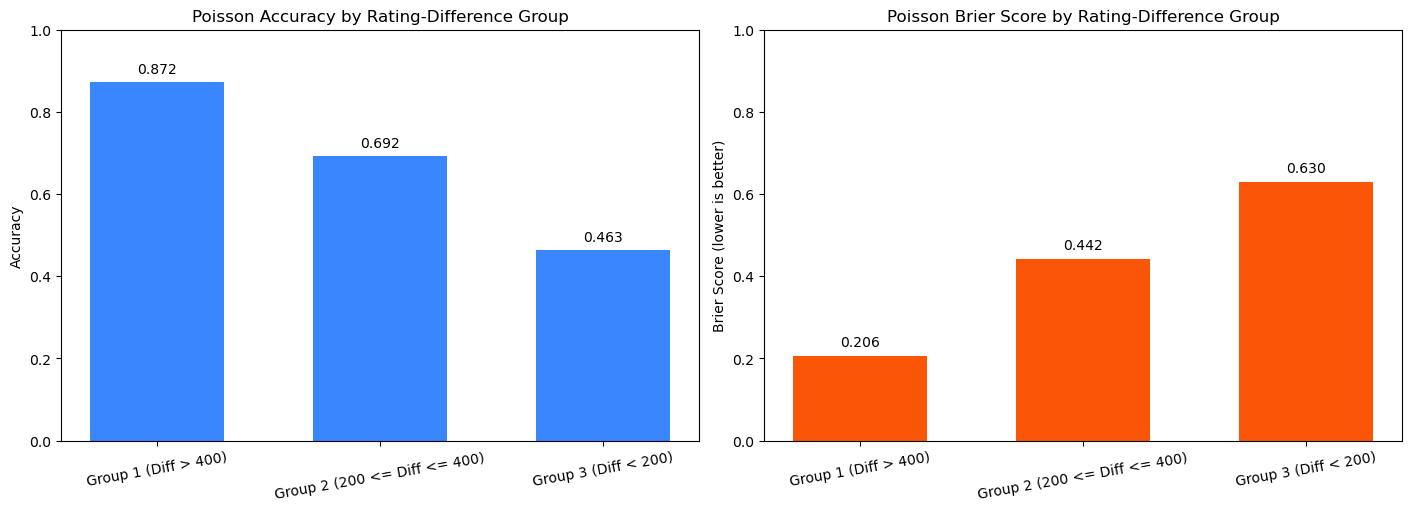

,Group,Accuracy,Brier Score
0,Group 1 (Diff > 400),0.871560,0.205779
1,Group 2 (200 <= Diff <= 400),0.692308,0.442006
2,Group 3 (Diff < 200),0.463087,0.630125


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# 1. Add the Glicko rating difference to the results for grouping
poisson_results['rating_diff'] = (
    afc_matches_final.loc[test_mask, 'home_glicko_rating'] -
    afc_matches_final.loc[test_mask, 'away_glicko_rating']
).abs()

# 2. Define groups based on rating difference
groups = [
    ('Group 1 (Diff > 400)', poisson_results['rating_diff'] > 400),
    ('Group 2 (200 <= Diff <= 400)', (poisson_results['rating_diff'] >= 200) & (poisson_results['rating_diff'] <= 400)),
    ('Group 3 (Diff < 200)', poisson_results['rating_diff'] < 200),
]

# 3. Collect Accuracy + Brier per group
labels = []
accuracies = []
brier_scores = []

class_order = ['Home Win', 'Draw', 'Away Win']

for group_name, mask in groups:
    group_data = poisson_results[mask]
    labels.append(group_name)

    if len(group_data) == 0:
        accuracies.append(np.nan)
        brier_scores.append(np.nan)
        continue

    acc = accuracy_score(group_data['result'], group_data['predicted_result_Poisson'])

    y_true = pd.get_dummies(group_data['result']).reindex(columns=class_order, fill_value=0).to_numpy()
    y_prob = group_data[['prob_Home Win_Poisson', 'prob_Draw_Poisson', 'prob_Away Win_Poisson']].rename(columns={
        'prob_Home Win_Poisson': 'Home Win',
        'prob_Draw_Poisson': 'Draw',
        'prob_Away Win_Poisson': 'Away Win',
    })[class_order].to_numpy()
    brier = np.mean(np.sum((y_prob - y_true) ** 2, axis=1))

    accuracies.append(acc)
    brier_scores.append(brier)

# 4. Plot group-wise metrics
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

bars_acc = axes[0].bar(x, accuracies, color='#3A86FF', width=0.6)
axes[0].set_title('Poisson Accuracy by Rating-Difference Group')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=10)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for bar in bars_acc:
    h = bar.get_height()
    if np.isfinite(h):
        axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.015, f'{h:.3f}', ha='center', va='bottom', fontsize=10)

bars_brier = axes[1].bar(x, brier_scores, color='#FB5607', width=0.6)
axes[1].set_title('Poisson Brier Score by Rating-Difference Group')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=10)
axes[1].set_ylabel('Brier Score (lower is better)')
max_brier = np.nanmax(brier_scores) if np.isfinite(np.nanmax(brier_scores)) else 1.0
axes[1].set_ylim(0, max(1.0, max_brier * 1.15))
for bar in bars_brier:
    h = bar.get_height()
    if np.isfinite(h):
        axes[1].text(bar.get_x() + bar.get_width() / 2, h + 0.015, f'{h:.3f}', ha='center', va='bottom', fontsize=10)

plt.show()

# Optional summary table
pd.DataFrame({
    'Group': labels,
    'Accuracy': accuracies,
    'Brier Score': brier_scores
})

### Confusion Matrices by Rating-Difference Group
Shows class-level prediction behavior (Home Win, Draw, Away Win) within each rating-gap band.

- Values: Raw counts and row-normalized percentages
- Purpose: Identify which outcomes are confused most often

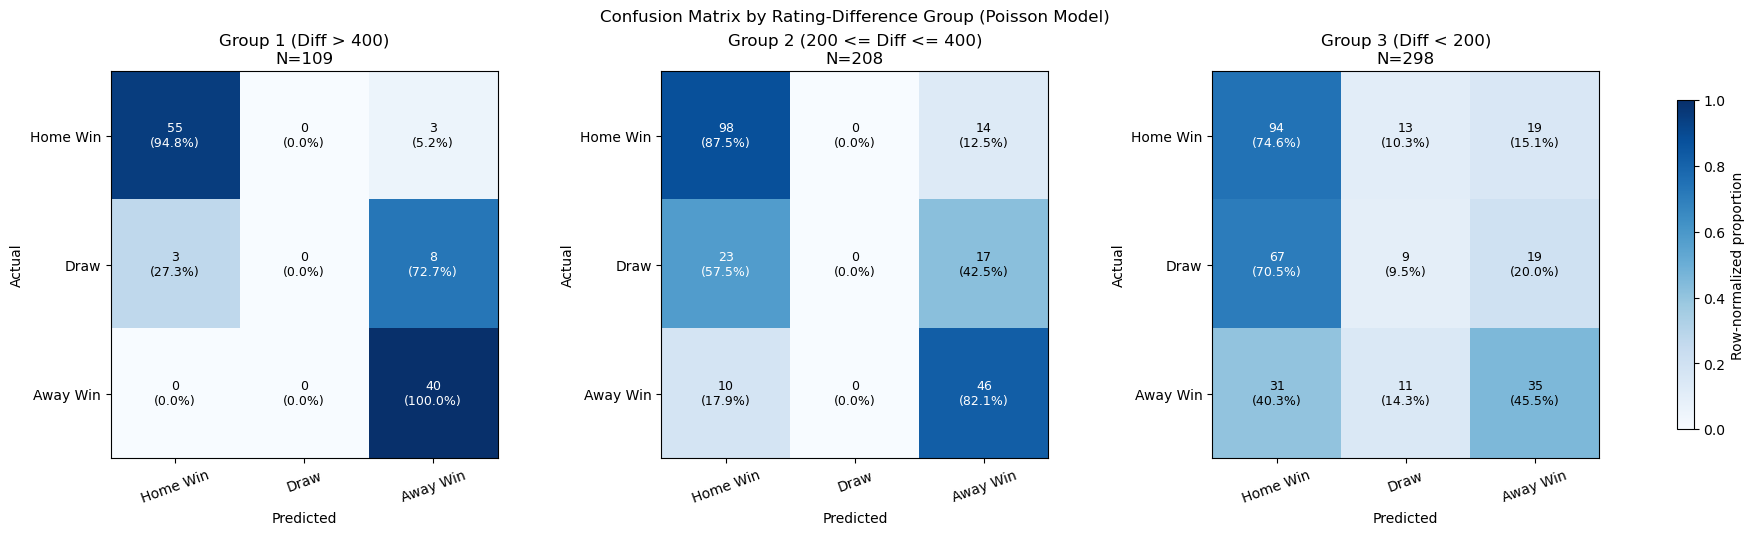

{'Group 1 (Diff > 400)':                   Pred: Home Win  Pred: Draw  Pred: Away Win
 Actual: Home Win              55           0               3
 Actual: Draw                   3           0               8
 Actual: Away Win               0           0              40,
 'Group 2 (200 <= Diff <= 400)':                   Pred: Home Win  Pred: Draw  Pred: Away Win
 Actual: Home Win              98           0              14
 Actual: Draw                  23           0              17
 Actual: Away Win              10           0              46,
 'Group 3 (Diff < 200)':                   Pred: Home Win  Pred: Draw  Pred: Away Win
 Actual: Home Win              94          13              19
 Actual: Draw                  67           9              19
 Actual: Away Win              31          11              35}

In [27]:
from sklearn.metrics import confusion_matrix

# Ensure groups exist if this cell is run independently
if 'groups' not in globals():
    poisson_results['rating_diff'] = (
        afc_matches_final.loc[test_mask, 'home_glicko_rating']
        - afc_matches_final.loc[test_mask, 'away_glicko_rating']
    ).abs()
    groups = [
        ('Group 1 (Diff > 400)', poisson_results['rating_diff'] > 400),
        ('Group 2 (200 <= Diff <= 400)', (poisson_results['rating_diff'] >= 200) & (poisson_results['rating_diff'] <= 400)),
        ('Group 3 (Diff < 200)', poisson_results['rating_diff'] < 200),
    ]

# Try to keep class order intuitive, with Draw in the middle when possible
preferred_orders = [
    ['Home Win', 'Draw', 'Away Win'],
    ['H', 'D', 'A'],
    ['home', 'draw', 'away'],
    ['Win', 'Draw', 'Loss'],
]
all_labels = pd.Index(poisson_results['result']).union(pd.Index(poisson_results['predicted_result_Poisson'])).tolist()
class_labels = None
for order in preferred_orders:
    if set(order).issubset(set(all_labels)):
        class_labels = order
        break
if class_labels is None:
    class_labels = sorted(all_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (group_name, mask) in zip(axes, groups):
    group_data = poisson_results[mask]

    if group_data.empty:
        ax.set_title(f'{group_name}\n(no matches)')
        ax.axis('off')
        continue

    y_true = group_data['result']
    y_pred = group_data['predicted_result_Poisson']

    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{group_name}\nN={len(group_data)}')
    ax.set_xticks(np.arange(len(class_labels)))
    ax.set_yticks(np.arange(len(class_labels)))
    ax.set_xticklabels(class_labels, rotation=20)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Show both raw counts and row-normalized percentage in each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            txt_color = 'white' if cm_norm[i, j] > 0.55 else 'black'
            ax.text(
                j,
                i,
                f"{cm[i, j]}\n({cm_norm[i, j]:.1%})",
                ha='center',
                va='center',
                color=txt_color,
                fontsize=9,
            )

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label('Row-normalized proportion')
plt.suptitle('Confusion Matrix by Rating-Difference Group (Poisson Model)', y=1.04)
plt.show()

# Optional: table view of per-group confusion matrices (raw counts)
cm_tables = {}
for group_name, mask in groups:
    group_data = poisson_results[mask]
    if group_data.empty:
        continue
    cm = confusion_matrix(group_data['result'], group_data['predicted_result_Poisson'], labels=class_labels)
    cm_tables[group_name] = pd.DataFrame(cm, index=[f'Actual: {c}' for c in class_labels], columns=[f'Pred: {c}' for c in class_labels])

cm_tables

# Part 4: Predict Fixtures for 31-03-2026
Builds pre-match features from historical data, estimates expected goals, and converts them into result probabilities.

- Inputs: Upcoming fixtures and team histories
- Outputs: Expected goals, win/draw/win probabilities, final predicted result

In [28]:
from collections import defaultdict, deque
from scipy.stats import poisson
import numpy as np
import pandas as pd

# Fixtures to predict (all on 31-03-2026)
match_date = pd.Timestamp('2026-03-31')
fixtures_input = [
    ('Maldives', 'Timor-Leste'),
    ('Tajikistan', 'Philippines'),
    ('Bhutan', 'Brunei'),
    ('Singapore', 'Bangladesh'),
    ('India', 'Hong Kong'),
    ('Chinese Taipei', 'Sri Lanka'),
    ('Thailand', 'Turkmenistan'),
    ('Pakistan', 'Myanmar'),
    ('Syria', 'Afghanistan'),
    ('Vietnam', 'Malaysia'),
    ('Laos', 'Nepal'),
]

# Name normalization to match model/training naming
team_alias = {
    'Chinese Taipei': 'Taiwan',
}


def normalize_team_name(team_name: str) -> str:
    return team_alias.get(team_name, team_name)


def get_form_stats(history):
    if not history:
        return {
            'W': 0.0, 'D': 0.0, 'L': 0.0,
            'GF': 0.0, 'GA': 0.0,
            'avg_opp': 1500.0,
            'games': 0,
            'avg_opp_W': 0.0,
            'avg_opp_D': 0.0,
            'avg_opp_L': 0.0,
        }

    n = len(history)
    wins = sum(x['W'] for x in history)
    draws = sum(x['D'] for x in history)
    losses = sum(x['L'] for x in history)
    gf = sum(x['GF'] for x in history)
    ga = sum(x['GA'] for x in history)
    avg_opp = sum(x['opp_post_rating'] for x in history) / n

    win_opp = [x['opp_post_rating'] for x in history if x['W'] == 1]
    draw_opp = [x['opp_post_rating'] for x in history if x['D'] == 1]
    loss_opp = [x['opp_post_rating'] for x in history if x['L'] == 1]

    return {
        'W': wins / n,
        'D': draws / n,
        'L': losses / n,
        'GF': gf / n,
        'GA': ga / n,
        'avg_opp': avg_opp,
        'games': n,
        'avg_opp_W': (sum(win_opp) / len(win_opp)) if win_opp else 0.0,
        'avg_opp_D': (sum(draw_opp) / len(draw_opp)) if draw_opp else 0.0,
        'avg_opp_L': (sum(loss_opp) / len(loss_opp)) if loss_opp else 0.0,
    }


def get_team_profile_features(team_name, target_year=2026):
    if 'country_year_profile_lookup' not in globals():
        return 0.0, 0.0

    team_slug = team_name_to_slug(team_name) if 'team_name_to_slug' in globals() else str(team_name).replace('-', '_').replace(' ', '_')
    team_rows = country_year_profile_lookup[country_year_profile_lookup['team_slug'] == team_slug]
    if team_rows.empty:
        return 0.0, 0.0

    exact = team_rows[team_rows['year'] == target_year]
    if not exact.empty:
        chosen = exact.iloc[-1]
    else:
        past = team_rows[team_rows['year'] <= target_year]
        chosen = past.sort_values('year').iloc[-1] if not past.empty else team_rows.sort_values('year').iloc[-1]

    age = float(chosen['team_age']) if pd.notna(chosen['team_age']) else 0.0
    height = float(chosen['team_height']) if pd.notna(chosen['team_height']) else 0.0
    return age, height


def calculate_match_probs_local(l_home, l_away, max_goals=10, rho=-0.125, apply_dixoncoles=True):
    # Use notebook-defined version if present
    if 'calculate_match_probs' in globals():
        return calculate_match_probs(l_home, l_away, max_goals=max_goals, rho=rho, apply_dixoncoles=apply_dixoncoles)

    prob_home = [poisson.pmf(i, l_home) for i in range(max_goals + 1)]
    prob_away = [poisson.pmf(i, l_away) for i in range(max_goals + 1)]
    score_matrix = np.outer(prob_home, prob_away)

    if apply_dixoncoles:
        tau_00 = 1 - (l_home * l_away * rho)
        tau_10 = 1 + (l_away * rho)
        tau_01 = 1 + (l_home * rho)
        tau_11 = 1 - rho
        score_matrix[0, 0] *= tau_00
        score_matrix[1, 0] *= tau_10
        score_matrix[0, 1] *= tau_01
        score_matrix[1, 1] *= tau_11

    home_win_prob = np.sum(np.tril(score_matrix, -1))
    away_win_prob = np.sum(np.triu(score_matrix, 1))
    draw_prob = np.sum(np.diag(score_matrix))
    total = home_win_prob + away_win_prob + draw_prob
    return home_win_prob / total, draw_prob / total, away_win_prob / total


# Build team states strictly from matches before 31-03-2026
hist_df = afc_matches_since_2000[afc_matches_since_2000['date'] < match_date].sort_values('date').copy()

ratings = {team: (1500.0, 350.0) for team in teams_in_asia}
form_hist = {team: deque(maxlen=10) for team in teams_in_asia}
h2h_hist = defaultdict(lambda: deque(maxlen=5))

for _, row in hist_df.iterrows():
    home = row['home_team']
    away = row['away_team']
    h_score = row['home_score']
    a_score = row['away_score']

    r_h, rd_h = ratings[home]
    r_a, rd_a = ratings[away]

    new_rh, new_rdh = update_glicko(r_h, rd_h, r_a, rd_a, h_score, a_score, row['tournament'])
    new_ra, new_rda = update_glicko(r_a, rd_a, r_h, rd_h, a_score, h_score, row['tournament'])

    ratings[home] = (new_rh, new_rdh)
    ratings[away] = (new_ra, new_rda)

    h_res = 'W' if h_score > a_score else ('L' if h_score < a_score else 'D')
    form_hist[home].append({
        'W': 1 if h_res == 'W' else 0,
        'D': 1 if h_res == 'D' else 0,
        'L': 1 if h_res == 'L' else 0,
        'GF': h_score,
        'GA': a_score,
        'opp_post_rating': new_ra,
    })
    form_hist[away].append({
        'W': 1 if h_res == 'L' else 0,
        'D': 1 if h_res == 'D' else 0,
        'L': 1 if h_res == 'W' else 0,
        'GF': a_score,
        'GA': h_score,
        'opp_post_rating': new_rh,
    })

    pair_key = tuple(sorted([home, away]))
    winner = home if h_score > a_score else (away if h_score < a_score else 'Draw')
    h2h_hist[pair_key].append({
        'winner': winner,
        'home': home,
        'away': away,
        'h_score': h_score,
        'a_score': a_score,
    })


# Build feature rows and predict
pred_rows = []
for home_raw, away_raw in fixtures_input:
    home = normalize_team_name(home_raw)
    away = normalize_team_name(away_raw)

    if home not in ratings or away not in ratings:
        raise ValueError(f'Unknown team name in fixture: {home_raw} vs {away_raw}')

    h_r, h_rd = ratings[home]
    a_r, a_rd = ratings[away]

    h_form = get_form_stats(form_hist[home])
    a_form = get_form_stats(form_hist[away])

    pair_key = tuple(sorted([home, away]))
    history = h2h_hist[pair_key]
    h2h_n = len(history)

    h2h_home_win = sum(1 for x in history if x['winner'] == home)
    h2h_away_win = sum(1 for x in history if x['winner'] == away)
    h2h_draw = sum(1 for x in history if x['winner'] == 'Draw')

    h2h_home_goals = 0
    h2h_away_goals = 0
    for past in history:
        if past['home'] == home:
            h2h_home_goals += past['h_score']
            h2h_away_goals += past['a_score']
        else:
            h2h_home_goals += past['a_score']
            h2h_away_goals += past['h_score']

    home_age, home_height = get_team_profile_features(home, target_year=2026)
    away_age, away_height = get_team_profile_features(away, target_year=2026)

    match_features = {
        'neutral': False,
        'home_glicko_rating': h_r,
        'home_glicko_rd': h_rd,
        'away_glicko_rating': a_r,
        'away_glicko_rd': a_rd,
        'home_form_W': h_form['W'],
        'home_form_D': h_form['D'],
        'home_form_L': h_form['L'],
        'home_form_GF': h_form['GF'],
        'home_form_GA': h_form['GA'],
        'home_form_avg_opp_rating': h_form['avg_opp'],
        'home_form_games_max10': h_form['games'],
        'home_form_avg_opp_rating_W': h_form['avg_opp_W'],
        'home_form_avg_opp_rating_D': h_form['avg_opp_D'],
        'home_form_avg_opp_rating_L': h_form['avg_opp_L'],
        'away_form_W': a_form['W'],
        'away_form_D': a_form['D'],
        'away_form_L': a_form['L'],
        'away_form_GF': a_form['GF'],
        'away_form_GA': a_form['GA'],
        'away_form_avg_opp_rating': a_form['avg_opp'],
        'away_form_games_max10': a_form['games'],
        'away_form_avg_opp_rating_W': a_form['avg_opp_W'],
        'away_form_avg_opp_rating_D': a_form['avg_opp_D'],
        'away_form_avg_opp_rating_L': a_form['avg_opp_L'],
        'H2H_home_team_win': (h2h_home_win / h2h_n) if h2h_n > 0 else 0.0,
        'H2H_draw': (h2h_draw / h2h_n) if h2h_n > 0 else 0.0,
        'H2H_away_team_win': (h2h_away_win / h2h_n) if h2h_n > 0 else 0.0,
        'H2H_games_max5': h2h_n,
        'H2H_home_team_score_avg': (h2h_home_goals / h2h_n) if h2h_n > 0 else 0.0,
        'H2H_away_team_score_avg': (h2h_away_goals / h2h_n) if h2h_n > 0 else 0.0,
        'tournament_weight': 15,
        'home_team_age': home_age,
        'home_team_height': home_height,
        'away_team_age': away_age,
        'away_team_height': away_height,
        'glicko_rd_sum': h_rd + a_rd,
        'height_difference': home_height - away_height,
        'home_score_potential': h_form['GF'] + a_form['GA'],
        'away_score_potential': a_form['GF'] + h_form['GA'],
    }

    X_one = pd.DataFrame([match_features]).reindex(columns=features, fill_value=0).fillna(0)

    exp_home_goals = float(model_home.predict(X_one)[0])
    exp_away_goals = float(model_away.predict(X_one)[0])

    p_home, p_draw, p_away = calculate_match_probs_local(exp_home_goals, exp_away_goals)

    pred_rows.append({
        'date': match_date.date(),
        'home_team': home_raw,
        'away_team': away_raw,
        'expected_home_goals': exp_home_goals,
        'expected_away_goals': exp_away_goals,
        'prob_home_win': p_home,
        'prob_draw': p_draw,
        'prob_away_win': p_away,
    })

pred_31mar2026 = pd.DataFrame(pred_rows)
pred_31mar2026['predicted_result'] = pred_31mar2026[['prob_home_win', 'prob_draw', 'prob_away_win']].idxmax(axis=1).map({
    'prob_home_win': 'Home Win',
    'prob_draw': 'Draw',
    'prob_away_win': 'Away Win',
})

# Readable formatting
for c in ['expected_home_goals', 'expected_away_goals', 'prob_home_win', 'prob_draw', 'prob_away_win']:
    pred_31mar2026[c] = pred_31mar2026[c].round(4)

display(pred_31mar2026)

,date,home_team,away_team,expected_home_goals,expected_away_goals,prob_home_win,prob_draw,prob_away_win,predicted_result
0,2026-03-31,Maldives,Timor-Leste,1.6398,0.7952,0.5606,0.2735,0.1660,Home Win
1,2026-03-31,Tajikistan,Philippines,1.3972,0.9983,0.4452,0.3018,0.2529,Home Win
2,2026-03-31,Bhutan,Brunei,1.7978,0.8626,0.5814,0.2555,0.1631,Home Win
3,2026-03-31,Singapore,Bangladesh,1.6181,0.8215,0.5482,0.2768,0.1750,Home Win
4,2026-03-31,India,Hong Kong,1.1818,0.8735,0.4137,0.3316,0.2547,Home Win
5,2026-03-31,Chinese Taipei,Sri Lanka,1.4575,1.0480,0.4498,0.2940,0.2562,Home Win
6,2026-03-31,Thailand,Turkmenistan,1.7067,1.0461,0.5142,0.2681,0.2177,Home Win
7,2026-03-31,Pakistan,Myanmar,1.2647,1.0671,0.3923,0.3124,0.2953,Home Win
8,2026-03-31,Syria,Afghanistan,2.0518,0.7862,0.6565,0.2222,0.1213,Home Win
9,2026-03-31,Vietnam,Malaysia,1.2736,1.0573,0.3970,0.3121,0.2910,Home Win


# Part 5: Use Player and Coach data to approximate the level of skill of each player/coach

In [29]:
import pandas as pd

# Load the lineups and players data
lineups_df = pd.read_csv('downloaded_files/scrape_exports/afc_match_lineups_coaches.csv')
players_df = pd.read_csv('downloaded_files/scrape_exports/afc_players_data.csv')

# Merge the two datasets on the 'player_link' column
merged_df = pd.merge(lineups_df, players_df, on='player_link', how='left')

# Drop the duplicate scraped_at_utc column if it exists and display the first few rows
if 'scraped_at_utc_y' in merged_df.columns:
    merged_df.rename(columns={'scraped_at_utc_x': 'scraped_at_utc'}, inplace=True)
    merged_df.drop(columns=['scraped_at_utc_y'], inplace=True)

# Add tournament column based on afc_matches_with_features
# We need to match on date and either home_team or away_team
if 'afc_matches_with_features' in locals():
    # Convert dates to datetime objects for consistency
    merged_df['date'] = pd.to_datetime(merged_df['date'])
    afc_matches_with_features['date'] = pd.to_datetime(afc_matches_with_features['date'])
    
    # Create two lookup dictionaries for (date, home_team) and (date, away_team)
    home_lookup = afc_matches_with_features.set_index(['date', 'home_team'])['tournament'].to_dict()
    away_lookup = afc_matches_with_features.set_index(['date', 'away_team'])['tournament'].to_dict()
    
    # Function to get tournament for each row in merged_df
    def get_tournament(row):
        key = (row['date'], row['team'])
        return home_lookup.get(key) or away_lookup.get(key)

    merged_df['tournament'] = merged_df.apply(get_tournament, axis=1)

print(f"Lineups shape: {lineups_df.shape}")
print(f"Players shape: {players_df.shape}")
print(f"Merged shape: {merged_df.shape}")
merged_df.head()

Lineups shape: (209936, 16)
Players shape: (25281, 8)
Merged shape: (209936, 23)


,match_id,match_url,team,coach,player_name,player_order,scraped_at_utc,date,goals,assists,...,is_substitute,minutes_played,player_link,position,birth_year,height,peak_tier,peak_matches,best_league_info,tournament
0,1411/Kyrgyzstan_Afghanistan.html,https://national-football-teams.com/matches/re...,Kyrgyzstan,Nematjan Zakirov,Zamirbek Jumagulov,1.0,2026-04-23T10:48:33+00:00,2003-03-16,1.0,0.0,...,False,90.0,https://national-football-teams.com/player/365...,Striker,1972.0,1.80m,5.0,303.0,"('Kyrgyzstan', 'I')",AFC Asian Cup qualification
1,1411/Kyrgyzstan_Afghanistan.html,https://national-football-teams.com/matches/re...,Kyrgyzstan,Nematjan Zakirov,Vyacheslav Pryanishnikov,2.0,2026-04-23T10:48:33+00:00,2003-03-16,0.0,0.0,...,False,80.0,https://national-football-teams.com/player/365...,Striker,1976.0,1.77m,5.0,270.0,"('Kyrgyzstan', 'I')",AFC Asian Cup qualification
2,1411/Kyrgyzstan_Afghanistan.html,https://national-football-teams.com/matches/re...,Kyrgyzstan,Nematjan Zakirov,Vyacheslav Amin,3.0,2026-04-23T10:48:33+00:00,2003-03-16,0.0,0.0,...,False,90.0,https://national-football-teams.com/player/366...,Defender,1976.0,1.80m,5.0,235.0,"('Kyrgyzstan', 'I')",AFC Asian Cup qualification
3,1411/Kyrgyzstan_Afghanistan.html,https://national-football-teams.com/matches/re...,Kyrgyzstan,Nematjan Zakirov,Vladimir Salo,4.0,2026-04-23T10:48:33+00:00,2003-03-16,0.0,0.0,...,False,90.0,https://national-football-teams.com/player/366...,Defender,1974.0,1.75m,5.0,209.0,"('Kyrgyzstan', 'I')",AFC Asian Cup qualification
4,1411/Kyrgyzstan_Afghanistan.html,https://national-football-teams.com/matches/re...,Kyrgyzstan,Nematjan Zakirov,Zakir Jalilov,5.0,2026-04-23T10:48:33+00:00,2003-03-16,0.0,0.0,...,False,90.0,https://national-football-teams.com/player/366...,Goalkeeper,1972.0,1.87m,5.0,223.0,"('Kyrgyzstan', 'I')",AFC Asian Cup qualification


In [30]:
# Merge player data with match features from afc_matches_with_features

# 1. Reshape afc_matches_with_features into a team-centric perspective (Home)
home_perspective = afc_matches_with_features[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'home_glicko_rating', 'away_glicko_rating', 'neutral']].copy()
home_perspective.columns = ['date', 'team', 'opponent', 'team_goals', 'opponent_goals', 'team_glicko_rating', 'opponent_glicko_rating', 'neutral']
home_perspective['ground'] = home_perspective['neutral'].apply(lambda x: 'neutral' if x else 'home')
home_perspective.drop(columns=['neutral'], inplace=True)

# 2. Reshape afc_matches_with_features into a team-centric perspective (Away)
away_perspective = afc_matches_with_features[['date', 'away_team', 'home_team', 'away_score', 'home_score', 'away_glicko_rating', 'home_glicko_rating', 'neutral']].copy()
away_perspective.columns = ['date', 'team', 'opponent', 'team_goals', 'opponent_goals', 'team_glicko_rating', 'opponent_glicko_rating', 'neutral']
away_perspective['ground'] = away_perspective['neutral'].apply(lambda x: 'neutral' if x else 'away')
away_perspective.drop(columns=['neutral'], inplace=True)

# 3. Combine both perspectives
results_perspective = pd.concat([home_perspective, away_perspective], ignore_index=True)

# Calculate result (Win/Draw/Loss)
def get_match_result(row):
    if row['team_goals'] > row['opponent_goals']:
        return 'Win'
    elif row['team_goals'] < row['opponent_goals']:
        return 'Loss'
    return 'Draw'

results_perspective['result'] = results_perspective.apply(get_match_result, axis=1)

# Ensure 'date' format is consistent before joining
merged_df['date'] = pd.to_datetime(merged_df['date'])
results_perspective['date'] = pd.to_datetime(results_perspective['date'])

# 4. Merge the datasets. Use an outer join to accurately find gaps in both datasets.
full_merged_df = pd.merge(merged_df, results_perspective, on=['date', 'team'], how='outer', indicator=True)

# 5. Extract the required datasets
# 5a. Players in matches that's NOT on the recorded list (removed from main dataset)
# They have '_merge' == 'left_only'
players_missing_match_data = full_merged_df[full_merged_df['_merge'] == 'left_only'].drop(columns=['_merge'])

# 5b. Recorded games with NO player data yet (set aside)
# They have '_merge' == 'right_only'
games_missing_player_data = full_merged_df[full_merged_df['_merge'] == 'right_only'].drop(columns=['_merge'])

# 5c. The successfully combined table
player_match_results_df = full_merged_df[full_merged_df['_merge'] == 'both'].drop(columns=['_merge']).reset_index(drop=True)

# Ensure we have a single `position` column available after merges
for pos_col in ['position', 'position_x', 'position_y']:
    if pos_col in player_match_results_df.columns:
        player_match_results_df['position'] = player_match_results_df[pos_col]
        break
if 'position' not in player_match_results_df.columns:
    player_match_results_df['position'] = None

print(f"Successfully combined player-match records: {player_match_results_df.shape[0]}")
print(f"Recorded games without player data yet: {games_missing_player_data[['date', 'team']].drop_duplicates().shape[0]} matches (x2 for both teams)")
print(f"Player records without a valid match in list: {players_missing_match_data.shape[0]}")

player_match_results_df

Successfully combined player-match records: 143323
Recorded games without player data yet: 154 matches (x2 for both teams)
Player records without a valid match in list: 66655


,match_id,match_url,team,coach,player_name,player_order,scraped_at_utc,date,goals,assists,...,peak_matches,best_league_info,tournament,opponent,team_goals,opponent_goals,team_glicko_rating,opponent_glicko_rating,ground,result
0,27381/Australia_Japan.html,https://national-football-teams.com/matches/re...,Australia,Eddie Thomson,Tony Popović,1.0,2026-04-23T10:49:28+00:00,1995-02-15,0.0,0.0,...,23.0,"('England', 'I')",Friendly,Japan,2.0,1.0,1500.000000,1500.00000,home,Win
1,27381/Australia_Japan.html,https://national-football-teams.com/matches/re...,Australia,Eddie Thomson,Željko Kalac,2.0,2026-04-23T10:49:28+00:00,1995-02-15,0.0,0.0,...,86.0,"('Italy', 'I')",Friendly,Japan,2.0,1.0,1500.000000,1500.00000,home,Win
2,27381/Australia_Japan.html,https://national-football-teams.com/matches/re...,Australia,Eddie Thomson,Stan Lazaridis,3.0,2026-04-23T10:49:28+00:00,1995-02-15,0.0,0.0,...,162.0,"('England', 'I')",Friendly,Japan,2.0,1.0,1500.000000,1500.00000,home,Win
3,27381/Australia_Japan.html,https://national-football-teams.com/matches/re...,Australia,Eddie Thomson,Tony Vidmar,4.0,2026-04-23T10:49:28+00:00,1995-02-15,0.0,0.0,...,12.0,"('England', 'I')",Friendly,Japan,2.0,1.0,1500.000000,1500.00000,home,Win
4,27381/Australia_Japan.html,https://national-football-teams.com/matches/re...,Australia,Eddie Thomson,Steve Corica,5.0,2026-04-23T10:49:28+00:00,1995-02-15,1.0,0.0,...,47.0,"('Japan', 'I')",Friendly,Japan,2.0,1.0,1500.000000,1500.00000,home,Win
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143318,42845/Saudi_Arabia_Jordan.html,https://national-football-teams.com/matches/re...,Saudi Arabia,Hervé Renard,Abdulrahman Al-Oboud,12.0,2026-04-23T12:00:28+00:00,2025-12-15,0.0,0.0,...,163.0,"('Saudi_Arabia', 'I')",Arab Cup,Jordan,0.0,1.0,1851.298938,1730.31698,neutral,Loss
143319,42845/Saudi_Arabia_Jordan.html,https://national-football-teams.com/matches/re...,Saudi Arabia,Hervé Renard,Musab Al-Juwayr,13.0,2026-04-23T12:00:28+00:00,2025-12-15,0.0,0.0,...,56.0,"('Saudi_Arabia', 'I')",Arab Cup,Jordan,0.0,1.0,1851.298938,1730.31698,neutral,Loss
143320,42845/Saudi_Arabia_Jordan.html,https://national-football-teams.com/matches/re...,Saudi Arabia,Hervé Renard,Abdullah Al-Hamdan,14.0,2026-04-23T12:00:28+00:00,2025-12-15,0.0,0.0,...,107.0,"('Saudi_Arabia', 'I')",Arab Cup,Jordan,0.0,1.0,1851.298938,1730.31698,neutral,Loss
143321,42845/Saudi_Arabia_Jordan.html,https://national-football-teams.com/matches/re...,Saudi Arabia,Hervé Renard,Mohammed Abu Al-Shamat,15.0,2026-04-23T12:00:28+00:00,2025-12-15,0.0,0.0,...,31.0,"('Saudi_Arabia', 'I')",Arab Cup,Jordan,0.0,1.0,1851.298938,1730.31698,neutral,Loss


In [31]:
import numpy as np

def get_position_multipliers(position):
    """Returns (offense_multiplier, defense_multiplier, group) based on player role."""
    pos_map = {
        'Goalkeeper': (0.1, 1.5, 'GK'),
        'Centre Back': (0.5, 1.2, 'DF'),
        'Defender': (0.5, 1.2, 'DF'),
        'Sweeper': (0.5, 1.3, 'DF'),
        'Libero': (0.7, 1.1, 'DF'),
        'Left Back': (0.6, 1.1, 'DF'),
        'Right Back': (0.6, 1.1, 'DF'),
        'Left Wing-Back': (0.8, 1.0, 'DF'),
        'Striker': (1.5, 0.3, 'FW'),
        'Centre Forward': (1.5, 0.3, 'FW'),
        'Secondary striker': (1.4, 0.4, 'FW'),
        'Attacking Midfielder': (1.3, 0.6, 'MF'),
        'Left Midfielder': (1.1, 0.8, 'MF'),
        'Right Midfielder': (1.1, 0.8, 'MF'),
        'Centre Midfielder': (1.0, 0.9, 'MF'),
        'Midfielder': (1.0, 0.9, 'MF'),
        'Defensive Midfielder': (0.8, 1.1, 'MF'),
        'Left Winger': (1.25, 0.5, 'FW'),
        'Right Winger': (1.25, 0.5, 'FW'),
    }
    
    # Clean and check position
    pos_str = str(position).strip()
    if pos_str in pos_map:
        return pos_map[pos_str]
    
    # Default for unknown or Nan
    return (1.0, 1.0, 'UNK')

class PlayerGlicko2:
    def __init__(self, rating=1500, rd=350, vol=0.06, tau=1):
        # Glicko-2 uses a scale where 1500 is approx 0
        self.r = (rating - 1500) / 173.7178
        self.rd = rd / 173.7178
        self.sigma = vol # volatility
        self.tau = tau   # system constraint
        
    def get_rating(self):
        return (self.r * 173.7178) + 1500
        
    def get_rd(self):
        return self.rd * 173.7178

    def _g(self, phi):
        return 1 / np.sqrt(1 + 3 * (phi**2) / (np.pi**2))

    def _E(self, mu, mu_j, phi_j):
        return 1 / (1 + np.exp(-self._g(phi_j) * (mu - mu_j)))

    def update(self, opponent_r, opponent_rd, outcome, multiplier=1.0, t_weight=20):
        """
        Full Glicko-2 update including iterative volatility estimation.
        outcome: 1.0 for win, 0.5 for draw, 0.0 for loss
        multiplier: Performance-based adjustment
        t_weight: Tournament importance weight (standardized around 20)
        """
        # Convert parameters to Glicko-2 scale
        mu = self.r
        phi = self.rd
        sigma = self.sigma
        
        mu_j = (opponent_r - 1500) / 173.7178
        phi_j = opponent_rd / 173.7178
        
        # Step 3: Compute variance v
        v = 1 / (self._g(phi_j)**2 * self._E(mu, mu_j, phi_j) * (1 - self._E(mu, mu_j, phi_j)))
        
        # Step 4: Compute delta
        delta = v * self._g(phi_j) * (outcome - self._E(mu, mu_j, phi_j))
        
        # Step 5: Iterative volatility update (Illinois algorithm)
        a = np.log(sigma**2)
        tau = self.tau
        
        def f(x):
            ex = np.exp(x)
            d2 = delta**2
            p2 = phi**2
            num = ex * (d2 - p2 - v - ex)
            den = 2 * (p2 + v + ex)**2
            return num / den - (x - a) / (tau**2)
            
        A = a
        if delta**2 > phi**2 + v:
            B = np.log(delta**2 - phi**2 - v)
        else:
            k = 1
            while f(a - k * tau) < 0:
                k += 1
            B = a - k * tau
            
        fa = f(A)
        fb = f(B)
        
        while abs(B - A) > 1e-6:
            C = A + (A - B) * fa / (fb - fa)
            fc = f(C)
            if fc * fb <= 0:
                A = B
                fa = fb
            else:
                fa = fa / 2
            B = C
            fb = fc
            
        new_sigma = np.exp(A / 2)
        
        # Step 6: Update rating deviation and rating
        phi_star = np.sqrt(phi**2 + new_sigma**2)
        new_phi = 1 / np.sqrt(1 / (phi_star**2) + 1 / v)
        
        # Standard Glicko scale adjustment
        rating_step = (new_phi**2) * self._g(phi_j) * (outcome - self._E(mu, mu_j, phi_j))
        
        # Apply performance multiplier AND tournament weight (scaled by 20) to the magnitude of change
        weight_factor = (t_weight / 20.0)
        self.r = mu + (rating_step * multiplier * weight_factor)
        self.rd = new_phi
        self.sigma = new_sigma

# Initialize player ratings dictionary
player_ratings = {}

print("Glicko-2 System with Dynamic Volatility and Tournament Weighting Initialized.")

Glicko-2 System with Dynamic Volatility and Tournament Weighting Initialized.


In [32]:
# Process matches chronologically to update player ratings
player_match_results_df['date'] = pd.to_datetime(player_match_results_df['date'])
chrono_players = player_match_results_df.sort_values('date').copy()

# Add tournament column to chrono_players if it's missing (it should be in results_perspective)
if 'tournament' not in chrono_players.columns:
    chrono_players = pd.merge(chrono_players, afc_matches_with_features[['date', 'home_team', 'away_team', 'tournament']], 
                              left_on=['date', 'team'], right_on=['date', 'home_team'], how='left')
    # If not home team, try away team
    # (Checking if it needs more complex merge logic or if tournament was already added to merged_df)

# Outcome mapping
outcome_map = {'Win': 1.0, 'Draw': 0.5, 'Loss': 0.0}

# Store historical ratings for analysis
player_history = []
player_ratings = {} # Reset to apply weightings from scratch

for idx, row in chrono_players.iterrows():
    p_link = row['player_link']
    p_name = row.get('player_name', 'Unknown')
    pos = row['position']
    match_result = row['result']
    outcome = outcome_map.get(match_result, 0.5)
    
    # Tournament context
    tournament = row.get('tournament', 'Friendly')
    t_weight = tournament_weight(tournament)
    
    # Team context
    team_goals = row['team_goals']
    opp_goals = row['opponent_goals']
    opp_rating = row['opponent_glicko_rating']
    
    # Individual stats
    ind_goals = row.get('goals', 0)
    ind_assists = row.get('assists', 0)
    yellow_cards = row.get('yellow_card', 0)
    red_cards = row.get('red_card', 0)
    
    # Initialize player if new
    if p_link not in player_ratings:
        base_r = 1500
        if 'peak_tier' in row and not pd.isna(row['peak_tier']):
            base_r = 1600 - (float(row['peak_tier']) * 50)
        player_ratings[p_link] = PlayerGlicko2(rating=base_r)
        
    p_obj = player_ratings[p_link]
    
    # Calculate performance multipliers
    off_mult, def_mult, p_group = get_position_multipliers(pos)
    
    # Logic for performance adjustment
    pos_actions = (ind_goals * 0.2 * off_mult) + (ind_assists * 0.1 * off_mult)
    if opp_goals == 0: pos_actions += (0.2 * def_mult)
    neg_actions = (yellow_cards * 0.1) + (red_cards * 0.3) + (max(0, opp_goals - 1) * 0.05 * def_mult)

    final_adjustment = 1.0
    if outcome < 0.5: # LOSS
        final_adjustment = 1.0 - pos_actions + neg_actions
    elif outcome > 0.5: # WIN
        final_adjustment = 1.0 + pos_actions - neg_actions
    else: # DRAW
        final_adjustment = 1.0 + pos_actions - neg_actions
        
    perf_multiplier = max(0.5, min(2.0, final_adjustment))
    
    # Store pre-update rating
    pre_r = p_obj.get_rating()
    
    # Apply Glicko-2 Update with Tournament Weight
    p_obj.update(
        opponent_r=opp_rating, 
        opponent_rd=100, 
        outcome=outcome, 
        multiplier=perf_multiplier,
        t_weight=t_weight
    )
    
    # Store for history
    player_history.append({
        'player_link': p_link,
        'player_name': p_name,
        'date': row['date'],
        'team': row['team'],
        'position': pos,
        'tournament': tournament,
        'pre_rating': pre_r,
        'post_rating': p_obj.get_rating(),
        'multiplier': perf_multiplier,
        't_weight': t_weight,
        'result': match_result
    })

history_df = pd.DataFrame(player_history)
print(f"Processed {len(history_df)} player-match instances with tournament weighting.")
history_df.tail(10)

Processed 143323 player-match instances with tournament weighting.


,player_link,player_name,date,team,position,tournament,pre_rating,post_rating,multiplier,t_weight,result
143313,https://national-football-teams.com/player/721...,Ahmad Ersan Hamdouni,2025-12-15,Jordan,Left Winger,Arab Cup,1706.328963,1728.201483,1.10,15,Win
143314,https://national-football-teams.com/player/836...,Abdallah Mousa Nasib,2025-12-15,Jordan,Centre Back,Arab Cup,1863.666125,1876.431565,1.24,15,Win
143315,https://national-football-teams.com/player/836...,Nizar Al-Rashdan,2025-12-15,Jordan,Defensive Midfielder,Arab Cup,1842.985003,1861.512271,1.38,15,Win
143316,https://national-football-teams.com/player/926...,Mohannad Abu Taha,2025-12-15,Jordan,Left Winger,Arab Cup,1880.616778,1898.819631,1.10,15,Win
143317,https://national-football-teams.com/player/955...,Husam Abu Dahab,2025-12-15,Jordan,Centre Back,Arab Cup,1754.920009,1800.600236,1.24,15,Win
143318,https://national-football-teams.com/player/812...,Saed Al-Rosan,2025-12-15,Jordan,Centre Back,Arab Cup,1743.733999,1794.827077,1.24,15,Win
143319,https://national-football-teams.com/player/681...,Yazeed Abu Laila,2025-12-15,Jordan,Goalkeeper,Arab Cup,1829.317637,1842.791290,1.30,15,Win
143320,https://national-football-teams.com/player/896...,Mohammed Abu Al-Shamat,2025-12-15,Saudi Arabia,Right Back,Arab Cup,1544.188895,1504.657701,1.00,15,Loss
143321,https://national-football-teams.com/player/958...,Ali Hajabi,2025-12-15,Jordan,Left Back,Arab Cup,1761.328043,1873.144367,1.22,15,Win
143322,https://national-football-teams.com/player/805...,Saleh Al-Shehri,2025-12-15,Saudi Arabia,Centre Forward,Arab Cup,1888.561680,1866.989902,1.00,15,Loss


In [33]:
# Final step: Generate the latest player ratings dataframe using vectorized grouping
if 'history_df' in globals() and not history_df.empty:
    # 1. Get the latest metadata (name, team, position, date) for every player link
    final_metadata = history_df.sort_values('date').groupby('player_link').last().reset_index()
    
    # 2. Extract final ratings from the player_ratings objects
    rating_data = []
    for p_link, p_obj in player_ratings.items():
        rating_data.append({
            'player_link': p_link,
            'rating': p_obj.get_rating(),
            'rd': p_obj.get_rd(),
            'volatility': getattr(p_obj, 'sigma', 0.06)
        })
    ratings_df = pd.DataFrame(rating_data)
    
    # 3. Merge metadata with ratings
    final_ratings_df = pd.merge(
        final_metadata[['player_link', 'player_name', 'team', 'position', 'date']], 
        ratings_df, 
        on='player_link'
    )
    
    # Clean up and sort
    final_ratings_df.rename(columns={'date': 'last_active'}, inplace=True)
    final_ratings_df = final_ratings_df.sort_values('rating', ascending=False).reset_index(drop=True)

    # 4. Filter for active/reliable players (Optional: e.g., RD < 80)
    # final_ratings_df = final_ratings_df[final_ratings_df['rd'] < 100]

    # Display top 20 players
    print(f"Total players rated: {len(final_ratings_df)}")
    cols_to_show = ['player_name', 'rating', 'team', 'position', 'last_active', 'rd', 'player_link']
    display(final_ratings_df[cols_to_show].head(20))
else:
    print("Error: history_df is empty or not defined. Please run the match processing cell first.")

Total players rated: 10855


,player_name,rating,team,position,last_active,rd,player_link
0,Ryan Teague,2174.165082,Australia,Defensive Midfielder,2025-06-10,208.878077,https://national-football-teams.com/player/989...
1,Ali Ghawas,2124.387701,United Arab Emirates,Midfielder,1996-12-15,238.210577,https://national-football-teams.com/player/666...
2,Daiki Iwamasa,2122.709326,Japan,Centre Back,2011-01-29,183.562499,https://national-football-teams.com/player/338...
3,Sami Al-Lenqawi,2112.423835,Kuwait,Defender,1996-12-21,235.028086,https://national-football-teams.com/player/666...
4,Yūta Nakayama,2109.309589,Japan,Centre Back,2024-01-31,144.021980,https://national-football-teams.com/player/746...
5,Sei Muroya,2101.174091,Japan,Right Back,2021-09-07,161.464530,https://national-football-teams.com/player/698...
6,Hyung-Seok Jang,2086.881133,South Korea,Defender,1997-11-09,193.640341,https://national-football-teams.com/player/275...
7,Masahiko Inoha,2073.691998,Japan,Centre Back,2013-06-11,146.412457,https://national-football-teams.com/player/414...
8,Ao Tanaka,2069.633283,Japan,Centre Midfielder,2025-03-25,109.724569,https://national-football-teams.com/player/764...
9,Kaoru Mitoma,2066.376577,Japan,Left Midfielder,2025-03-20,123.559726,https://national-football-teams.com/player/847...


In [34]:
final_ratings_df.tail(20)

,player_link,player_name,team,position,last_active,rating,rd,volatility
10835,https://national-football-teams.com/player/273...,Dave Borja,Guam,Striker,2003-04-25,657.243989,271.019646,0.060025
10836,https://national-football-teams.com/player/488...,Daniel Westphal,Northern Mariana Islands,Defender,2013-03-06,637.817947,194.934461,0.060021
10837,https://national-football-teams.com/player/303...,Steven Clark McKagan,Northern Mariana Islands,Midfielder,2013-03-06,596.469535,147.619960,0.060026
10838,https://national-football-teams.com/player/302...,Nicolas Benjamin Swaim,Northern Mariana Islands,Defender,2018-09-04,561.859716,122.851136,0.059992
10839,https://national-football-teams.com/player/488...,William Dunn,Northern Mariana Islands,Midfielder,2016-07-04,555.742298,163.164505,0.060006
10840,https://national-football-teams.com/player/302...,Peter Benjamin Loken,Northern Mariana Islands,Defender,2013-03-06,544.313995,170.731221,0.060006
10841,https://national-football-teams.com/player/619...,Bruce Berline,Northern Mariana Islands,Striker,2007-04-01,544.239636,271.294742,0.060050
10842,https://national-football-teams.com/player/992...,Jordan Smith,Guam,Goalkeeper,2003-04-25,519.361421,293.042939,0.060027
10843,https://national-football-teams.com/player/229...,Ric-Francis Mantanona,Guam,Midfielder,2007-06-17,516.843585,227.500336,0.060017
10844,https://national-football-teams.com/player/619...,Mark McDonald,Northern Mariana Islands,unknown,2007-04-01,511.216422,297.213252,0.060062


In [35]:
min_rd = 20
max_rd = 200

vn_stable_players = final_ratings_df[
(final_ratings_df['team'] == 'Vietnam') &
(final_ratings_df['rd'] >= min_rd) &
(final_ratings_df['rd'] <= max_rd)
].sort_values('rating', ascending=False)

vn_stable_players.head(20)

,player_link,player_name,team,position,last_active,rating,rd,volatility
693,https://national-football-teams.com/player/969...,Rafaelson,Vietnam,Centre Forward,2025-11-19,1826.656887,154.951965,0.059975
1568,https://national-football-teams.com/player/765...,Mạnh Dũng Đỗ,Vietnam,Defender,1999-08-08,1717.003017,167.192844,0.059996
1747,https://national-football-teams.com/player/968...,Ngọc Tân Doãn,Vietnam,Centre Midfielder,2025-03-19,1700.229508,136.548705,0.059981
1779,https://national-football-teams.com/player/876...,Văn Vĩ Nguyễn,Vietnam,Left Midfielder,2025-11-19,1697.526984,116.836996,0.059980
1807,https://national-football-teams.com/player/683...,Văn Lâm Đặng,Vietnam,Goalkeeper,2025-11-19,1694.917667,78.526236,0.059807
1911,https://national-football-teams.com/player/933...,Hai Long Nguyễn,Vietnam,Centre Midfielder,2025-11-19,1684.048036,131.052774,0.060001
1962,https://national-football-teams.com/player/709...,Đình Trọng Trần,Vietnam,Centre Back,2022-09-21,1679.240749,119.569724,0.059958
1975,https://national-football-teams.com/player/311...,Việt Hoàng Trương,Vietnam,Midfielder,2000-08-25,1678.241237,116.789070,0.059987
2022,https://national-football-teams.com/player/764...,Tiến Anh Trần,Vietnam,Goalkeeper,1999-01-29,1672.845816,134.013613,0.059991
2118,https://national-football-teams.com/player/688...,Văn Hậu Đoàn,Vietnam,Left Back,2023-06-20,1663.295278,76.673454,0.059822


In [36]:
final_ratings_df[
(final_ratings_df['player_name'] == 'Quang Hải Nguyễn')]

,player_link,player_name,team,position,last_active,rating,rd,volatility
2338,https://national-football-teams.com/player/683...,Quang Hải Nguyễn,Vietnam,Attacking Midfielder,2025-11-19,1643.092691,68.840139,0.059730
5141,https://national-football-teams.com/player/298...,Quang Hải Nguyễn,Vietnam,Striker,2015-05-17,1446.887388,79.778569,0.059998


In [37]:
# Initialize coach ratings dictionary
coach_ratings = {}

# Process matches chronologically to update coach ratings
# First, extract unique coach-match events from lineups_df
coach_match_events = lineups_df[['date', 'team', 'coach']].dropna(subset=['coach']).copy()
coach_match_events['date'] = pd.to_datetime(coach_match_events['date'])

# Merge with match results to get team, opponent performance AND tournament
# results_perspective already includes 'tournament'
coach_match_results = pd.merge(coach_match_events, results_perspective, on=['date', 'team'], how='inner')

# Identify unique matches to avoid double counting
coach_match_results = coach_match_results.drop_duplicates(subset=['date', 'team', 'coach']).sort_values('date')

coach_history = []

for idx, row in coach_match_results.iterrows():
    c_name = row['coach']
    match_result = row['result']
    outcome = outcome_map.get(match_result, 0.5)
    
    # Tournament importance weight
    tournament = row.get('tournament', 'Friendly')
    t_weight = tournament_weight(tournament)
    
    # Team performance metrics
    team_goals = row['team_goals']
    opp_goals = row['opponent_goals']
    opp_rating = row['opponent_glicko_rating']
    
    # Initialize coach if new
    if c_name not in coach_ratings:
         coach_ratings[c_name] = PlayerGlicko2(rating=1500, rd=350, vol=0.06, tau=0.5)
        
    c_obj = coach_ratings[c_name]
    
    pos_actions = (0.05 * team_goals) + (0.2 if opp_goals == 0 else 0)
    neg_actions = (0.05 * max(0, opp_goals - 1))
    
    # Logic similar to players: mitigate loss if the team scored well, amplify gain if big win
    final_adjustment = 1.0
    if outcome < 0.5: # LOSS
        final_adjustment = 1.0 - pos_actions + neg_actions
    else: # WIN or DRAW
        final_adjustment = 1.0 + pos_actions - neg_actions
        
    perf_multiplier = max(0.5, min(2.0, final_adjustment))
    
    pre_r = c_obj.get_rating()
    
    # Update coach rating with performance multiplier and tournament weight
    c_obj.update(
        opponent_r=opp_rating, 
        opponent_rd=100, 
        outcome=outcome, 
        multiplier=perf_multiplier,
        t_weight=t_weight
    )
    
    coach_history.append({
        'coach': c_name,
        'date': row['date'],
        'team': row['team'],
        'tournament': tournament,
        'pre_rating': pre_r,
        'post_rating': c_obj.get_rating(),
        'multiplier': perf_multiplier,
        't_weight': t_weight,
        'score': f"{int(team_goals)}-{int(opp_goals)}"
    })

coach_history_df = pd.DataFrame(coach_history)
print(f"Processed {len(coach_history_df)} coach-match records with tournament weighting.")
coach_history_df.tail(10)

Processed 10396 coach-match records with tournament weighting.


,coach,date,team,tournament,pre_rating,post_rating,multiplier,t_weight,score
10386,José Lana,2025-12-07,Syria,Friendly,1588.936734,1587.139896,1.20,5,0-0
10387,Ihab Abu Jazar,2025-12-07,Palestine,Friendly,1609.956459,1611.193159,1.20,5,0-0
10388,Cosmin Olăroiu,2025-12-09,United Arab Emirates,Friendly,1565.779017,1578.054013,1.15,5,3-1
10389,Hélio Sousa,2025-12-09,Kuwait,Friendly,1751.166181,1747.166395,1.05,5,1-3
10390,Hervé Renard,2025-12-11,Saudi Arabia,Friendly,1735.416102,1737.358702,1.10,5,2-1
10391,Ihab Abu Jazar,2025-12-11,Palestine,Friendly,1611.193159,1605.891564,1.00,5,1-2
10392,Graham Arnold,2025-12-12,Iraq,Friendly,1798.284663,1794.517859,1.00,5,0-1
10393,Jamel Sellami,2025-12-12,Jordan,Friendly,1677.927333,1687.652366,1.25,5,1-0
10394,Jamel Sellami,2025-12-15,Jordan,Friendly,1687.652366,1698.501289,1.25,5,1-0
10395,Hervé Renard,2025-12-15,Saudi Arabia,Friendly,1737.358702,1733.785946,1.00,5,0-1


In [38]:
import pandas as pd
import numpy as np

# 1. Define Position to Role Mapping
def get_role(position):
    pos_map = {
        'Goalkeeper': 'GK',
        'Centre Back': 'DF', 'Defender': 'DF', 'Sweeper': 'DF', 'Libero': 'DF',
        'Left Back': 'DF', 'Right Back': 'DF', 'Left Wing-Back': 'DF', 'Right Wing-Back': 'DF',
        'Striker': 'FW', 'Centre Forward': 'FW', 'Secondary striker': 'FW', 'Left Winger': 'FW', 'Right Winger': 'FW',
        'Attacking Midfielder': 'MF', 'Left Midfielder': 'MF', 'Right Midfielder': 'MF',
        'Centre Midfielder': 'MF', 'Midfielder': 'MF', 'Defensive Midfielder': 'MF'
    }
    return pos_map.get(str(position).strip(), 'UNK')

# 2. Extract specific pre-game stats from history_df
player_stats_for_merge = history_df[['date', 'team', 'player_link', 'position', 'pre_rating']].copy()
player_stats_for_merge['role'] = player_stats_for_merge['position'].apply(get_role)

# 3. Aggregate Player Ratings per Team-Match
player_match_agg = player_stats_for_merge.groupby(['date', 'team'])['pre_rating'].agg(['mean', 'std', 'count']).reset_index()
player_match_agg.columns = ['date', 'team', 'avg_player_rating', 'std_player_rating', 'player_count']

# Role-based average
role_match_agg = player_stats_for_merge.groupby(['date', 'team', 'role'])['pre_rating'].mean().unstack(fill_value=np.nan).reset_index()
role_match_agg.columns = ['date', 'team'] + [f'avg_{r}_rating' for r in role_match_agg.columns if r not in ['date', 'team']]

# 4. Extract Coach Ratings
coach_stats_for_merge = coach_history_df[['date', 'team', 'pre_rating']].copy()
coach_stats_for_merge.rename(columns={'pre_rating': 'coach_rating'}, inplace=True)

# 5. Merge Features back into afc_poisson_df
afc_poisson_df = afc_matches_final.copy()
afc_poisson_df['date'] = pd.to_datetime(afc_poisson_df['date'])
afc_poisson_df = afc_poisson_df.sort_values('date')

# Function to carry forward last known stats for a team
def merge_and_ffill(base_df, feature_df, prefix):
    # Merge on date and team
    merged = pd.merge(base_df, feature_df, left_on=['date', prefix+'_team'], right_on=['date', 'team'], how='left')
    merged.drop(columns=['team'], inplace=True)
    
    # Identify feature columns
    feat_cols = [c for c in feature_df.columns if c not in ['date', 'team']]
    renamed_cols = {c: f'{prefix}_{c}' for c in feat_cols}
    merged.rename(columns=renamed_cols, inplace=True)
    
    # Sort and forward fill per team
    team_col = prefix + '_team'
    target_cols = [f'{prefix}_{c}' for c in feat_cols]
    
    # Group by team and ffill
    merged[target_cols] = merged.groupby(team_col, group_keys=False)[target_cols].apply(lambda x: x.ffill())
    
    # Final cleanup: fill remaining NaNs with 1500
    merged[target_cols] = merged[target_cols].fillna(1500)
    
    return merged

# Merge Home/Away Player Stats with ffill
afc_poisson_df = merge_and_ffill(afc_poisson_df, player_match_agg, 'home')
afc_poisson_df = merge_and_ffill(afc_poisson_df, player_match_agg, 'away')

# Merge Home/Away Role Stats with ffill
afc_poisson_df = merge_and_ffill(afc_poisson_df, role_match_agg, 'home')
afc_poisson_df = merge_and_ffill(afc_poisson_df, role_match_agg, 'away')

# Merge Home/Away Coach Stats with ffill
afc_poisson_df = merge_and_ffill(afc_poisson_df, coach_stats_for_merge, 'home')
afc_poisson_df = merge_and_ffill(afc_poisson_df, coach_stats_for_merge, 'away')

# 7. Add Difference Columns
afc_poisson_df['player_rating_difference'] = afc_poisson_df['home_avg_player_rating'] - afc_poisson_df['away_avg_player_rating']

for role in ['GK', 'DF', 'MF', 'FW']:
    h_col, a_col = f'home_avg_{role}_rating', f'away_avg_{role}_rating'
    if h_col in afc_poisson_df.columns and a_col in afc_poisson_df.columns:
        afc_poisson_df[f'player_rating_difference_{role}'] = afc_poisson_df[h_col] - afc_poisson_df[a_col]

afc_poisson_df['coach_rating_difference'] = afc_poisson_df['home_coach_rating'] - afc_poisson_df['away_coach_rating']

# Cleanup duplicate columns if any from multiple merges
afc_poisson_df = afc_poisson_df.loc[:, ~afc_poisson_df.columns.duplicated()]

print(f"Features added with forward-fill! New shape: {afc_poisson_df.shape}")
display(afc_poisson_df[['date', 'home_team', 'away_team', 'player_rating_difference', 'coach_rating_difference']].tail(5))

Features added with forward-fill! New shape: (5334, 78)


,date,home_team,away_team,player_rating_difference,coach_rating_difference
5329,2025-12-11,Palestine,Saudi Arabia,-117.546863,-124.222944
5330,2025-12-12,Jordan,Iraq,93.109833,-120.357330
5331,2025-12-15,Saudi Arabia,Jordan,28.263177,49.706336
5332,2026-01-26,Uzbekistan,China PR,242.826923,-158.021167
5333,2026-03-26,Vietnam,Bangladesh,282.719072,248.397220


In [39]:
print("afc_poisson_df index type:", type(afc_poisson_df.index))
print("afc_poisson_df shape:", afc_poisson_df.shape)
print("train_mask sum:", train_mask.sum())
print("val_mask sum:", val_mask.sum())
print("test_mask sum:", test_mask.sum())
print("Duplicate columns:", afc_poisson_df.columns[afc_poisson_df.columns.duplicated()].tolist())

afc_poisson_df index type: <class 'pandas.core.indexes.range.RangeIndex'>
afc_poisson_df shape: (5334, 78)
train_mask sum: 4306
val_mask sum: 348
test_mask sum: 615
Duplicate columns: []


In [40]:
# 1. Identify all rating-related columns that should be set to NaN if player data is missing (1500 default)
rating_suffixes = [
    'avg_player_rating', 'std_player_rating', 'player_count',
    'avg_DF_rating', 'avg_FW_rating', 'avg_GK_rating', 'avg_MF_rating', 'avg_UNK_rating',
    'coach_rating'
]

# 2. Set team-specific columns to NaN if their main average_player_rating is 1500
for side in ['home', 'away']:
    mask = afc_poisson_df[f'{side}_avg_player_rating'] == 1500
    for suffix in rating_suffixes:
        col_name = f'{side}_{suffix}'
        if col_name in afc_poisson_df.columns:
            afc_poisson_df.loc[mask, col_name] = np.nan

# 3. Handle rating difference columns: set to NaN if either home or away counterpart is NaN
diff_mappings = {
    'player_rating_difference': ('home_avg_player_rating', 'away_avg_player_rating'),
    'player_rating_difference_GK': ('home_avg_GK_rating', 'away_avg_GK_rating'),
    'player_rating_difference_DF': ('home_avg_DF_rating', 'away_avg_DF_rating'),
    'player_rating_difference_MF': ('home_avg_MF_rating', 'away_avg_MF_rating'),
    'player_rating_difference_FW': ('home_avg_FW_rating', 'away_avg_FW_rating'),
    'coach_rating_difference': ('home_coach_rating', 'away_coach_rating')
}

for diff_col, (h_col, a_col) in diff_mappings.items():
    if diff_col in afc_poisson_df.columns:
        # Set to NaN if either home or away value is NaN
        afc_poisson_df.loc[afc_poisson_df[h_col].isna() | afc_poisson_df[a_col].isna(), diff_col] = np.nan

# Display summary of NaNs created
print("Columns updated to NaN where data was missing (rating=1500):")
cols_to_check = [f'home_{s}' for s in rating_suffixes] + [f'away_{s}' for s in rating_suffixes] + list(diff_mappings.keys())
nan_counts = afc_poisson_df[afc_poisson_df.columns.intersection(cols_to_check)].isna().sum()
print(nan_counts[nan_counts > 0])

Columns updated to NaN where data was missing (rating=1500):
home_avg_player_rating         16
home_std_player_rating         16
home_player_count              16
away_avg_player_rating         14
away_std_player_rating         14
away_player_count              14
home_avg_DF_rating             16
home_avg_FW_rating             16
home_avg_GK_rating             16
home_avg_MF_rating             16
home_avg_UNK_rating            16
away_avg_DF_rating             14
away_avg_FW_rating             14
away_avg_GK_rating             14
away_avg_MF_rating             14
away_avg_UNK_rating            14
home_coach_rating              16
away_coach_rating              14
player_rating_difference       20
player_rating_difference_GK    20
player_rating_difference_DF    20
player_rating_difference_MF    20
player_rating_difference_FW    20
coach_rating_difference        20
dtype: int64


In [41]:
with pd.option_context('display.max_columns', None):
    display(afc_poisson_df)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_glicko_rating,home_glicko_rd,away_glicko_rating,away_glicko_rd,glicko_rating_diff,home_glicko_rating_post,away_glicko_rating_post,home_form_W,home_form_D,home_form_L,home_form_GF,home_form_GA,home_form_avg_opp_rating,home_form_games_max10,home_form_avg_opp_rating_W,home_form_avg_opp_rating_D,home_form_avg_opp_rating_L,home_form_streak,away_form_W,away_form_D,away_form_L,away_form_GF,away_form_GA,away_form_avg_opp_rating,away_form_games_max10,away_form_avg_opp_rating_W,away_form_avg_opp_rating_D,away_form_avg_opp_rating_L,away_form_streak,H2H_home_team_win,H2H_draw,H2H_away_team_win,H2H_games_max5,H2H_home_team_score_avg,H2H_away_team_score_avg,tournament_weight,result,home_team_age,home_team_height,away_team_age,away_team_height,glicko_rd_sum,height_difference,home_score_potential,away_score_potential,home_avg_player_rating,home_std_player_rating,home_player_count,away_avg_player_rating,away_std_player_rating,away_player_count,home_avg_DF_rating,home_avg_FW_rating,home_avg_GK_rating,home_avg_MF_rating,home_avg_UNK_rating,away_avg_DF_rating,away_avg_FW_rating,away_avg_GK_rating,away_avg_MF_rating,away_avg_UNK_rating,home_coach_rating,away_coach_rating,player_rating_difference,player_rating_difference_GK,player_rating_difference_DF,player_rating_difference_MF,player_rating_difference_FW,coach_rating_difference
0,1995-02-15,Australia,Japan,2.0,1.0,Friendly,Sydney,Australia,False,1500.000000,350.000000,1500.000000,350.000000,0.000000,1540.553001,1459.446999,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0,0.0,0.0,5,Home Win,24.7,1.84,25.6,1.77,700.000000,0.07,0.0,0.0,1476.923077,69.568266,13.0,NaN,NaN,NaN,1500.000000,1400.000000,1550.000000,1487.500000,1500.000000,NaN,NaN,NaN,NaN,NaN,1500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1995-02-19,China PR,South Korea,0.0,0.0,Dynasty Cup,Victoria,Hong Kong,True,1500.000000,350.000000,1500.000000,350.000000,0.000000,1500.000000,1500.000000,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0,0.0,0.0,5,Draw,22.9,1.80,23.9,1.80,700.000000,0.00,0.0,0.0,1503.846154,13.867505,13.0,1457.692308,53.409401,13.0,1500.000000,1510.000000,1500.000000,1500.000000,1500.000000,1433.333333,1475.000000,1450.000000,1487.500000,1500.000000,1500.000000,1500.000000,46.153846,50.000000,66.666667,12.500000,35.000000,0.000000
2,1995-02-19,Hong Kong,Japan,0.0,3.0,Dynasty Cup,Victoria,Hong Kong,False,1500.000000,350.000000,1459.446999,290.230506,40.553001,1408.884766,1526.160774,0.0,0.0,0.0,0.0,0.0,1500.000000,0,0.000000,0.000000,0.000000,0,0.0,0.0,1.0,1.0,2.0,1540.553001,1,0.000000,0.000000,1540.553001,-1,0.0,0.0,0.0,0,0.0,0.0,5,Away Win,0.0,0.00,25.6,1.77,640.230506,-1.77,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1995-02-21,Hong Kong,China PR,0.0,0.0,Dynasty Cup,Victoria,Hong Kong,False,1408.884766,281.582486,1500.000000,290.230506,-91.115234,1414.840712,1493.646530,0.0,0.0,1.0,0.0,3.0,1526.160774,1,0.000000,0.000000,1526.160774,-1,0.0,1.0,0.0,0.0,0.0,1500.000000,1,0.000000,1500.000000,0.000000,-1,0.0,0.0,0.0,0,0.0,0.0,5,Draw,0.0,0.00,22.9,1.80,571.812992,-1.80,0.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1995-02-21,Japan,South Korea,1.0,1.0,Dynasty Cup,Victoria,Hong Kong,True,1526.160774,253.529108,1500.000000,290.230506,26.160774,1524.698575,1501.945754,0.5,0.0,0.5,2.0,1.0,1474.718883,2,1408.884766,0.000000,1540.553001,1,0.0,1.0,0.0,0.0,0.0,1500.000000,1,0.000000,1500.000000,0.000000,-1,0.0,0.0,0.0,0,0.0,0.0,5,Draw,25.6,1.77,23.9,1.80,543.759614,-0.03,2.0,1.0,1458.124624,13.209540,12.0,1446.998799,68.468245,11.0,1469.167478,1455.227242,1452.985871,1454.024555,1500.000000,1415.230917,1478.188091,1457.819845,1451.419603,1500.000000,1456.

In [42]:
import xgboost as xgb
from scipy.stats import poisson
import numpy as np
import pandas as pd

# 0. Sync masks and features with current afc_poisson_df
# Use .values to extract the boolean array and avoid index alignment issues
train_mask_arr = ((afc_matches_final['date'].dt.year >= 1996) & (afc_matches_final['date'].dt.year <= 2019)).values
val_mask_arr = ((afc_matches_final['date'].dt.year >= 2020) & (afc_matches_final['date'].dt.year <= 2022)).values
test_mask_arr = ((afc_matches_final['date'].dt.year >= 2023) & (afc_matches_final['date'].dt.year <= 2026)).values

# Double check that the lengths match afc_poisson_df
if len(train_mask_arr) != len(afc_poisson_df):
    print(f"Warning: Mask length ({len(train_mask_arr)}) does not match dataframe length ({len(afc_poisson_df)}).")
    # If they don't match, we should define masks based on afc_poisson_df itself if it has a date column
    if 'date' in afc_poisson_df.columns:
        train_mask_arr = ((afc_poisson_df['date'].dt.year >= 1996) & (afc_poisson_df['date'].dt.year <= 2019)).values
        val_mask_arr = ((afc_poisson_df['date'].dt.year >= 2020) & (afc_poisson_df['date'].dt.year <= 2022)).values
        test_mask_arr = ((afc_poisson_df['date'].dt.year >= 2023) & (afc_poisson_df['date'].dt.year <= 2026)).values

# Define features consistently (exclude non-feature columns and non-numeric columns)
exclude_cols = ['date', 'home_team', 'away_team', 'home_score', 'away_score', 
    'tournament', 'city', 'country', 'result', 
    'home_glicko_rating_post', 'away_glicko_rating_post',
    'away_form_games_max10', 'home_form_games_max10', 'H2H_games_max5',
    'home_glicko_rd', 'away_glicko_rd', 
    'home_form_GF', 'home_form_GA', 'away_form_GF', 'away_form_GA', 
    'home_team_age', 'away_team_age',
    'home_form_streak', 'away_form_streak', 'predicted_result', 'home_player_count', 'away_player_count',
    'home_std_player_rating', 'away_std_player_rating']

# XGBoost requires numeric features
features = afc_poisson_df.select_dtypes(include=[np.number]).columns.tolist()
features = [col for col in features if col not in exclude_cols]

# Re-create X dataframes to ensure they match the masks using .iloc with the boolean array
X_train = afc_poisson_df.iloc[train_mask_arr, :][features]
X_val = afc_poisson_df.iloc[val_mask_arr, :][features]
X_test = afc_poisson_df.iloc[test_mask_arr, :][features]

# 1. Prepare target variables for Poisson models
y_train_home = afc_poisson_df.iloc[train_mask_arr]['home_score']
y_train_away = afc_poisson_df.iloc[train_mask_arr]['away_score']

y_val_home = afc_poisson_df.iloc[val_mask_arr]['home_score']
y_val_away = afc_poisson_df.iloc[val_mask_arr]['away_score']

y_test_home = afc_poisson_df.iloc[test_mask_arr]['home_score']
y_test_away = afc_poisson_df.iloc[test_mask_arr]['away_score']

# ... (rest of the cell)
# 2. Define and train XGBoost Poisson models
poisson_params = {
    'objective': 'count:poisson',
    'eval_metric': 'poisson-nloglik',
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'early_stopping_rounds': 50,
    'random_state': 42
}

model_home_poisson = xgb.XGBRegressor(**poisson_params, n_estimators=1000)
model_away_poisson = xgb.XGBRegressor(**poisson_params, n_estimators=1000)

print("Training Poisson model for Home Goals...")
model_home_poisson.fit(X_train, y_train_home, eval_set=[(X_val, y_val_home)], verbose=100)

print("\nTraining Poisson model for Away Goals...")
model_away_poisson.fit(X_train, y_train_away, eval_set=[(X_val, y_val_away)], verbose=100)

# 3. Predict Expected Goals (Lambda) for Test Set
lambda_home_test = model_home_poisson.predict(X_test)
lambda_away_test = model_away_poisson.predict(X_test)

# 4. Probabilistic Match Outcome Function
def get_poisson_probs(l_home, l_away, max_goals=10, rho=-0.125):
    # Probability of each score (0 to max_goals)
    prob_home = [poisson.pmf(i, l_home) for i in range(max_goals + 1)]
    prob_away = [poisson.pmf(i, l_away) for i in range(max_goals + 1)]
    
    # Outer product to get the score matrix
    score_matrix = np.outer(prob_home, prob_away)
    
    # Apply Dixon-Coles adjustment
    tau_00 = 1 - (l_home * l_away * rho)
    tau_10 = 1 + (l_away * rho)
    tau_01 = 1 + (l_home * rho)
    tau_11 = 1 - rho
    
    if max_goals >= 1:
        score_matrix[0, 0] *= max(0, tau_00)
        score_matrix[1, 0] *= max(0, tau_10)
        score_matrix[0, 1] *= max(0, tau_01)
        score_matrix[1, 1] *= max(0, tau_11)
    
    home_win = np.sum(np.tril(score_matrix, -1))
    away_win = np.sum(np.triu(score_matrix, 1))
    draw = np.sum(np.diag(score_matrix))
    
    total = home_win + away_win + draw
    if total == 0: return 0.33, 0.34, 0.33
    return home_win/total, draw/total, away_win/total

# Generate probabilities for the test set
test_poisson_probs = [get_poisson_probs(lh, la) for lh, la in zip(lambda_home_test, lambda_away_test)]
test_poisson_df = pd.DataFrame(test_poisson_probs, columns=['prob_Home Win', 'prob_Draw', 'prob_Away Win'], index=X_test.index)

# Evaluate and Show Results
poisson_results_df = afc_poisson_df.iloc[test_mask_arr][['date', 'home_team', 'away_team', 'home_score', 'away_score', 'result']].copy()
poisson_results_df['expected_home'] = lambda_home_test
poisson_results_df['expected_away'] = lambda_away_test
# Use concat with axis=1 and align on index (which we preserved for X_test)
poisson_results_df = pd.concat([poisson_results_df, test_poisson_df], axis=1)

# Prediction Column
poisson_results_df['predicted_result'] = poisson_results_df[['prob_Home Win', 'prob_Draw', 'prob_Away Win']].idxmax(axis=1).str.replace('prob_', '')

# Calculate accuracy
accuracy = (poisson_results_df['predicted_result'] == poisson_results_df['result']).mean()
print(f"\nPoisson Model Accuracy on Test Set (2023-2026): {accuracy:.2%}")

display(poisson_results_df.head(20))

Training Poisson model for Home Goals...
[0]	validation_0-poisson-nloglik:1.85977
[100]	validation_0-poisson-nloglik:1.52695
[200]	validation_0-poisson-nloglik:1.51947
[223]	validation_0-poisson-nloglik:1.52087

Training Poisson model for Away Goals...
[0]	validation_0-poisson-nloglik:1.46773
[100]	validation_0-poisson-nloglik:1.24303
[192]	validation_0-poisson-nloglik:1.24190

Poisson Model Accuracy on Test Set (2023-2026): 61.30%


,date,home_team,away_team,home_score,away_score,result,expected_home,expected_away,prob_Home Win,prob_Draw,prob_Away Win,predicted_result
4719,2023-01-02,Thailand,Cambodia,3.0,1.0,Home Win,4.279831,0.436377,0.951777,0.039653,0.008570,Home Win
4720,2023-01-02,Philippines,Indonesia,1.0,2.0,Away Win,0.975392,1.436061,0.240445,0.298186,0.461369,Away Win
4721,2023-01-03,Vietnam,Myanmar,3.0,0.0,Home Win,3.473230,0.442216,0.910399,0.072234,0.017367,Home Win
4722,2023-01-03,Malaysia,Singapore,4.0,1.0,Home Win,1.359238,0.917608,0.454348,0.308466,0.237185,Home Win
4723,2023-01-06,Yemen,Saudi Arabia,0.0,2.0,Away Win,0.691353,2.752089,0.060415,0.143792,0.795793,Away Win
4724,2023-01-06,Indonesia,Vietnam,0.0,0.0,Draw,1.081093,1.287238,0.295054,0.309511,0.395435,Away Win
4725,2023-01-06,Iraq,Oman,0.0,0.0,Draw,0.880477,1.029757,0.285458,0.349504,0.365038,Away Win
4726,2023-01-07,Bahrain,United Arab Emirates,2.0,1.0,Home Win,0.735532,0.765874,0.291837,0.398537,0.309625,Draw
4727,2023-01-07,Kuwait,Qatar,0.0,2.0,Away Win,0.878631,1.349637,0.227978,0.310624,0.461398,Away Win
4728,2023-01-07,Malaysia,Thailand,1.0,0.0,Home Win,0.835039,1.295993,0.224326,0.318540,0.457134,Away Win


In [45]:
from sklearn.metrics import brier_score_loss, mean_absolute_error, mean_squared_error
from scipy.special import gammaln

# Match indices or use boolean array as before to prevent IndexingError
# We use the test_mask_arr and afc_poisson_df.iloc to ensure absolute alignment
poisson_results_df['home_glicko_rating'] = afc_poisson_df.iloc[test_mask_arr]['home_glicko_rating'].values
poisson_results_df['away_glicko_rating'] = afc_poisson_df.iloc[test_mask_arr]['away_glicko_rating'].values
poisson_results_df['rating_diff'] = (poisson_results_df['home_glicko_rating'] - poisson_results_df['away_glicko_rating']).abs()

def poisson_nloglik(y_true, y_pred):
    """
    Calculates the true Poisson Negative Log-Likelihood.
    NLL = lambda - k*log(lambda) + log(k!)
    The previous version omitted the log(k!) term, which caused negative NLL values
    for high-scoring predictions common in high-rating disparity matches.
    """
    y_pred = np.maximum(y_pred, 1e-10)
    # Adding gammaln(y_true + 1) which is log(y_true!)
    return np.mean(y_pred - y_true * np.log(y_pred) + gammaln(y_true + 1))

def calculate_group_metrics(df):
    """Calculates all metrics for a given subset of matches."""
    if df.empty:
        return None
        
    # 1. Brier Score
    y_true_home = (df['result'] == 'Home Win').astype(int)
    y_true_draw = (df['result'] == 'Draw').astype(int)
    y_true_away = (df['result'] == 'Away Win').astype(int)
    brier = brier_score_loss(y_true_home, df['prob_Home Win']) + \
            brier_score_loss(y_true_draw, df['prob_Draw']) + \
            brier_score_loss(y_true_away, df['prob_Away Win'])
            
    # 2. Goal Prediction Metrics (MAE, RMSE, Log-lik)
    y_true_goals = np.concatenate([df['home_score'], df['away_score']])
    y_pred_goals = np.concatenate([df['expected_home'], df['expected_away']])
    
    mae = mean_absolute_error(y_true_goals, y_pred_goals)
    rmse = np.sqrt(mean_squared_error(y_true_goals, y_pred_goals))
    nll = poisson_nloglik(y_true_goals, y_pred_goals)
    
    # 3. Accuracy
    acc = (df['predicted_result'] == df['result']).mean()
    
    return {
        'count': len(df),
        'accuracy': acc,
        'brier': brier,
        'mae': mae,
        'rmse': rmse,
        'nll': nll
    }

# Calculate metrics for each group
group_high = poisson_results_df[poisson_results_df['rating_diff'] > 400]
group_mid = poisson_results_df[(poisson_results_df['rating_diff'] >= 200) & (poisson_results_df['rating_diff'] <= 400)]
group_low = poisson_results_df[poisson_results_df['rating_diff'] < 200]

all_stats = {
    "Total Match Set": calculate_group_metrics(poisson_results_df),
    "Rating Diff > 400": calculate_group_metrics(group_high),
    "Rating Diff 200-400": calculate_group_metrics(group_mid),
    "Rating Diff < 200": calculate_group_metrics(group_low)
}

# 3. Visualize as a Table
metrics_df = pd.DataFrame(all_stats).T
metrics_df = metrics_df[['count', 'accuracy', 'brier', 'mae', 'rmse', 'nll']]
metrics_df.columns = ['Sample Size', 'Accuracy', 'Brier Score', 'Goal MAE', 'Goal RMSE', 'Poisson NLL']

print("Model Performance Metrics by Rating Disparity (Test Set 2023-2026)")
print(metrics_df.to_string())
display(metrics_df.style.format({
    'Sample Size': '{:.0f}',
    'Accuracy': '{:.2%}',
    'Brier Score': '{:.4f}',
    'Goal MAE': '{:.4f}',
    'Goal RMSE': '{:.4f}',
    'Poisson NLL': '{:.4f}'
}))

Model Performance Metrics by Rating Disparity (Test Set 2023-2026)
                     Sample Size  Accuracy  Brier Score  Goal MAE  Goal RMSE  Poisson NLL
Total Match Set            615.0  0.613008     0.497754  0.884568   1.169474     1.385185
Rating Diff > 400          109.0  0.871560     0.218187  1.118897   1.544427     1.515312
Rating Diff 200-400        208.0  0.697115     0.456524  0.887333   1.152620     1.396070
Rating Diff < 200          298.0  0.459732     0.628790  0.796927   1.011328     1.329991


,Sample Size,Accuracy,Brier Score,Goal MAE,Goal RMSE,Poisson NLL
Total Match Set,615,61.30%,0.4978,0.8846,1.1695,1.3852
Rating Diff > 400,109,87.16%,0.2182,1.1189,1.5444,1.5153
Rating Diff 200-400,208,69.71%,0.4565,0.8873,1.1526,1.3961
Rating Diff < 200,298,45.97%,0.6288,0.7969,1.0113,1.3300


/tmp/ipykernel_4928/3955925127.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, ax=ax, palette='viridis')
/tmp/ipykernel_4928/3955925127.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, ax=ax, palette='viridis')


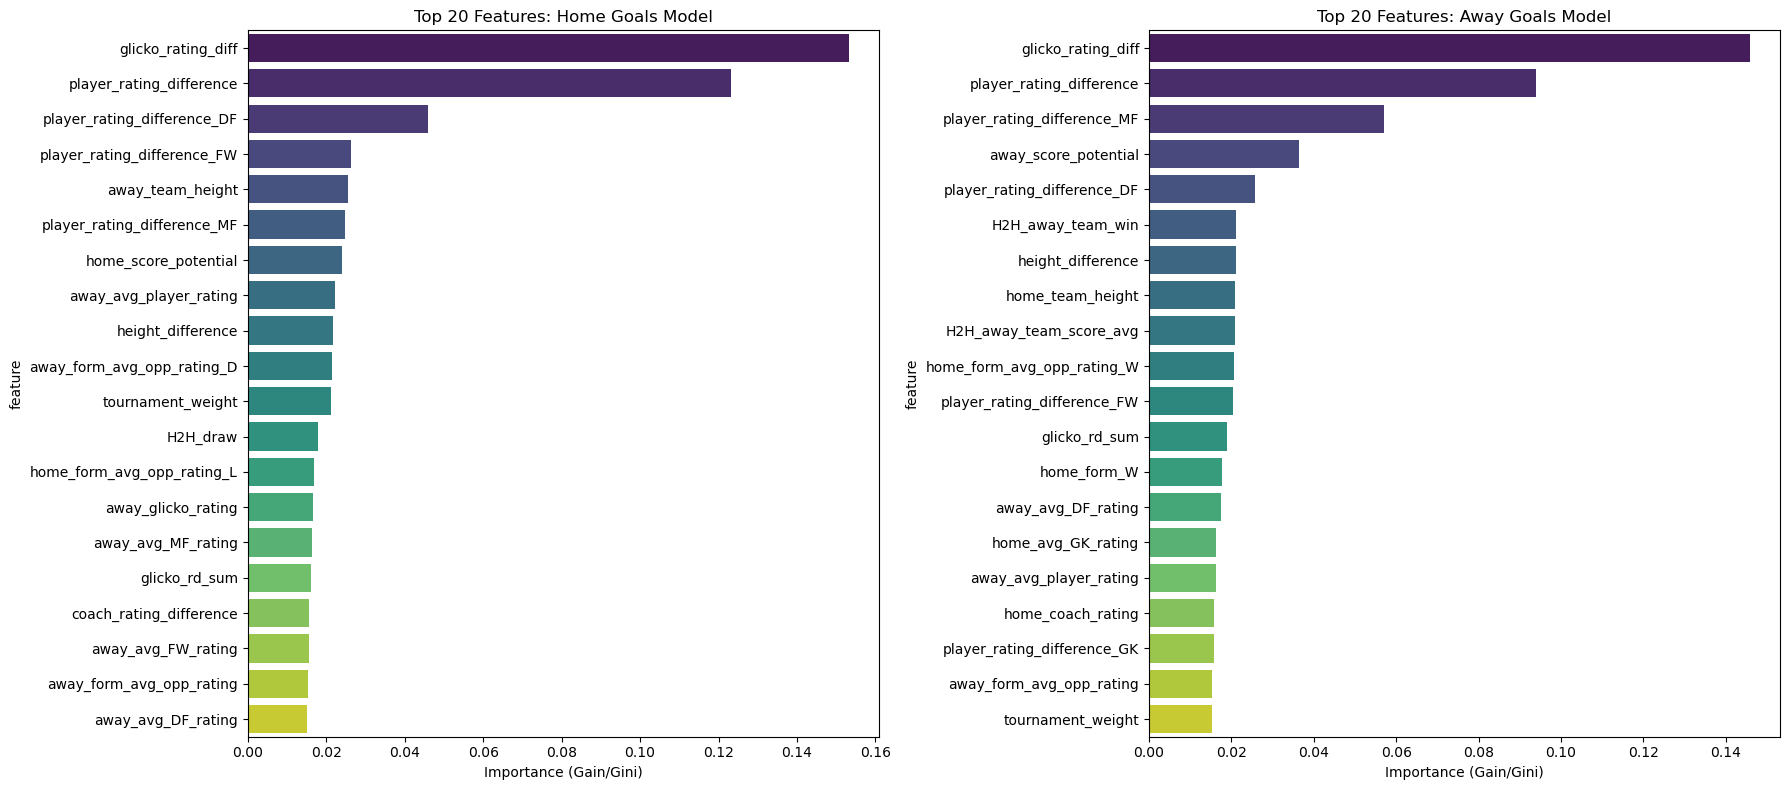

Top 10 Features (Home Goals):
glicko_rating_diff             0.153169
player_rating_difference       0.123116
player_rating_difference_DF    0.046046
player_rating_difference_FW    0.026370
away_team_height               0.025525
player_rating_difference_MF    0.024892
home_score_potential           0.023986
away_avg_player_rating         0.022321
height_difference              0.021830
away_form_avg_opp_rating_D     0.021389
dtype: float32


In [46]:
# Feature Importance for the Poisson Models
import matplotlib.pyplot as plt
import seaborn as sns

# We have two models: Home Goals and Away Goals. 
# Let's visualize the top features for both.

def plot_importance(model, title, ax):
    # Get importance
    importance = model.feature_importances_
    importance_df = pd.DataFrame({'feature': features, 'importance': importance})
    importance_df = importance_df.sort_values(by='importance', ascending=False).head(20)
    
    sns.barplot(x='importance', y='feature', data=importance_df, ax=ax, palette='viridis')
    ax.set_title(title)
    ax.set_xlabel('Importance (Gain/Gini)')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plot_importance(model_home_poisson, 'Top 20 Features: Home Goals Model', axes[0])
plot_importance(model_away_poisson, 'Top 20 Features: Away Goals Model', axes[1])

plt.tight_layout()
plt.show()

# Print Top 10 numerical values for verification
top_10_home = pd.Series(model_home_poisson.feature_importances_, index=features).sort_values(ascending=False).head(10)
print("Top 10 Features (Home Goals):")
print(top_10_home)


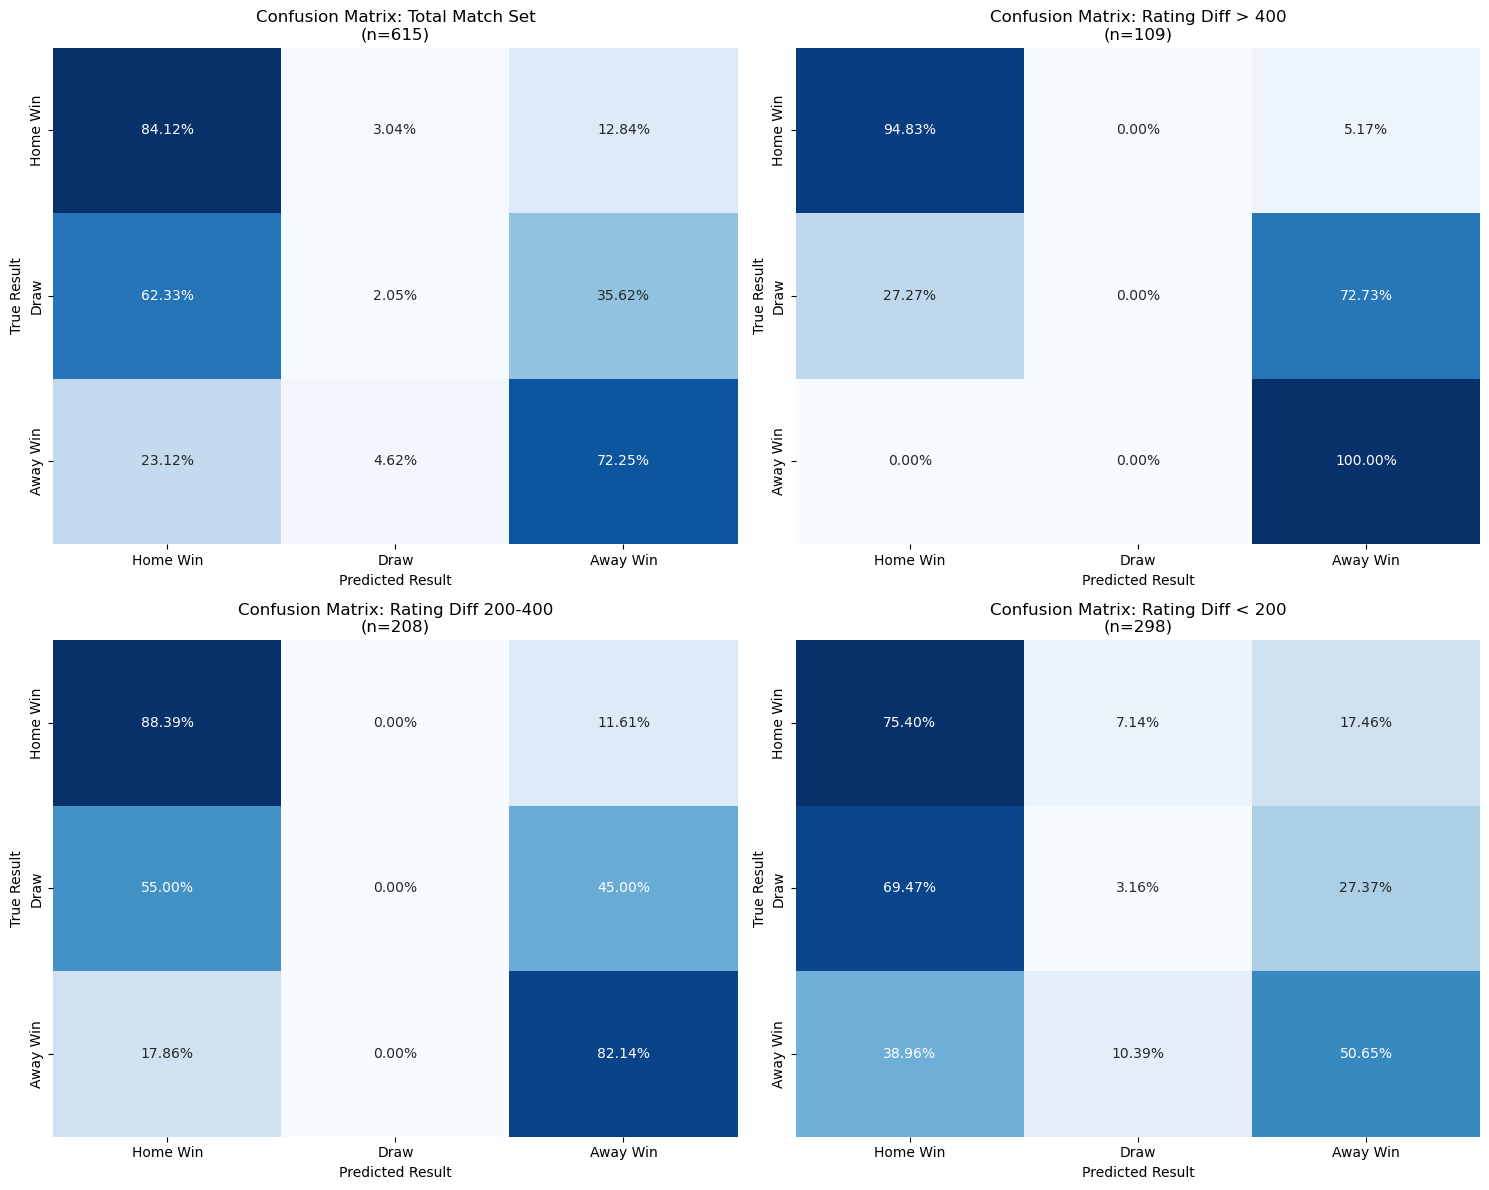

Numerical Confusion Matrix (Total Match Set):


,Pred Home Win,Pred Draw,Pred Away Win
True Home Win,249,9,38
True Draw,91,3,52
True Away Win,40,8,125


In [47]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define the order of classes for consistent display
class_order = ['Home Win', 'Draw', 'Away Win']

# 1. Total Confusion Matrix
cm = confusion_matrix(poisson_results_df['result'], poisson_results_df['predicted_result'], labels=class_order)

# 2. Confusion matrices for groups
groups = {
    "Total Match Set": poisson_results_df,
    "Rating Diff > 400": group_high,
    "Rating Diff 200-400": group_mid,
    "Rating Diff < 200": group_low
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, group_df) in enumerate(groups.items()):
    ax = axes[i]
    if group_df.empty:
        ax.set_title(f"{name} (No data)")
        continue
        
    group_cm = confusion_matrix(group_df['result'], group_df['predicted_result'], labels=class_order)
    
    # Normalize by row (true labels) to show recall/accuracy per class
    group_cm_norm = group_cm.astype('float') / group_cm.sum(axis=1)[:, np.newaxis]
    group_cm_norm = np.nan_to_num(group_cm_norm) # handle div by zero
    
    sns.heatmap(group_cm_norm, annot=True, fmt='.2%', cmap='Blues', 
                xticklabels=class_order, yticklabels=class_order, ax=ax, cbar=False)
    
    ax.set_title(f"Confusion Matrix: {name}\n(n={len(group_df)})")
    ax.set_xlabel('Predicted Result')
    ax.set_ylabel('True Result')

plt.tight_layout()
plt.show()

# Numerical Breakdown
print("Numerical Confusion Matrix (Total Match Set):")
cm_df = pd.DataFrame(cm, index=[f"True {c}" for c in class_order], columns=[f"Pred {c}" for c in class_order])
display(cm_df)

In [51]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, brier_score_loss, mean_absolute_error, mean_squared_error
from scipy.special import gammaln
import numpy as np
import pandas as pd

def run_experiment(df, features, seeds=[42, 123, 456, 789, 1011, 1, 69, 420, 727, 67, 2, 3, 4, 5, 6], description="Model"):
    results = []
    
    # Define masks based on the provided dataframe
    exp_train_mask = (df['date'].dt.year >= 1996) & (df['date'].dt.year <= 2019)
    exp_val_mask = (df['date'].dt.year >= 2020) & (df['date'].dt.year <= 2022)
    exp_test_mask = (df['date'].dt.year >= 2023) & (df['date'].dt.year <= 2026)
    
    X_train_exp = df.loc[exp_train_mask, features]
    X_val_exp = df.loc[exp_val_mask, features]
    X_test_exp = df.loc[exp_test_mask, features]
    
    y_train_h = df.loc[exp_train_mask, 'home_score']
    y_train_a = df.loc[exp_train_mask, 'away_score']
    y_val_h = df.loc[exp_val_mask, 'home_score']
    y_val_a = df.loc[exp_val_mask, 'away_score']
    
    y_test_h = df.loc[exp_test_mask, 'home_score']
    y_test_a = df.loc[exp_test_mask, 'away_score']
    y_test_res = df.loc[exp_test_mask, 'result']
    
    # Target goals for MAE/RMSE calculation
    y_test_goals_all = np.concatenate([y_test_h.values, y_test_a.values])

    def poisson_nloglik(y_true, y_pred):
        """Calculates true Poisson NLL including log-factorial term."""
        y_pred = np.maximum(y_pred, 1e-10)
        return np.mean(y_pred - y_true * np.log(y_pred) + gammaln(y_true + 1))

    for seed in seeds:
        params = {
            'objective': 'count:poisson',
            'eval_metric': 'poisson-nloglik',
            'learning_rate': 0.05,
            'max_depth': 5,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'early_stopping_rounds': 50,
            'random_state': seed
        }
        
        m_h = xgb.XGBRegressor(**params, n_estimators=1000)
        m_a = xgb.XGBRegressor(**params, n_estimators=1000)
        
        m_h.fit(X_train_exp, y_train_h, eval_set=[(X_val_exp, y_val_h)], verbose=False)
        m_a.fit(X_train_exp, y_train_a, eval_set=[(X_val_exp, y_val_a)], verbose=False)
        
        l_h = m_h.predict(X_test_exp)
        l_a = m_a.predict(X_test_exp)
        
        # Merge lambda predictions for goal metrics
        l_all = np.concatenate([l_h, l_a])
        
        # Accuracy & Brier Score (Outcome based)
        probs = [get_poisson_probs(lh, la) for lh, la in zip(l_h, l_a)]
        probs_df = pd.DataFrame(probs, columns=['Home Win', 'Draw', 'Away Win'])
        preds = probs_df.idxmax(axis=1)
        
        acc = accuracy_score(y_test_res, preds)
        
        y_true_h = (y_test_res == 'Home Win').astype(int).values
        y_true_d = (y_test_res == 'Draw').astype(int).values
        y_true_a = (y_test_res == 'Away Win').astype(int).values
        
        brier = brier_score_loss(y_true_h, probs_df['Home Win']) + \
                brier_score_loss(y_true_d, probs_df['Draw']) + \
                brier_score_loss(y_true_a, probs_df['Away Win'])
        
        # Goal metrics
        mae = mean_absolute_error(y_test_goals_all, l_all)
        rmse = np.sqrt(mean_squared_error(y_test_goals_all, l_all))
        nll = poisson_nloglik(y_test_goals_all, l_all)
                
        results.append({
            'seed': seed, 
            'accuracy': acc, 
            'brier': brier,
            'mae': mae,
            'rmse': rmse,
            'nll': nll
        })
    
    res_df = pd.DataFrame(results)
    print(f"\nResults for {description}:")
    print(f"Mean Accuracy:    {res_df['accuracy'].mean():.4f} (+/- {res_df['accuracy'].std():.4f})")
    print(f"Mean Brier Score: {res_df['brier'].mean():.4f} (+/- {res_df['brier'].std():.4f})")
    print(f"Mean Goal MAE:    {res_df['mae'].mean():.4f}")
    print(f"Mean Goal RMSE:   {res_df['rmse'].mean():.4f}")
    print(f"Mean Poisson NLL: {res_df['nll'].mean():.4f}")
    return res_df

# 1. Test Base Model
exclude_base = ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'result']
features_base = [col for col in afc_matches_final.select_dtypes(include=[np.number]).columns if col not in exclude_base]
# Filter out ANY columns that hint at the new features
features_base = [f for f in features_base if 'player' not in f and 'coach' not in f and 'GK' not in f and 'DF' not in f and 'MF' not in f and 'FW' not in f and 'difference' not in f]

res_base = run_experiment(afc_matches_final, features_base, description="Base Model (Basic Data)")

# 2. Test Enhanced Model (Includes the new difference features)
exclude_enhanced = ['date', 'home_team', 'away_team', 'home_score', 'away_score', 
    'tournament', 'city', 'country', 'result', 
    'home_glicko_rating_post', 'away_glicko_rating_post',
    'away_form_games_max10', 'home_form_games_max10', 'H2H_games_max5',
    'home_glicko_rd', 'away_glicko_rd', 
    'home_form_GF', 'home_form_GA', 'away_form_GF', 'away_form_GA', 
    'home_team_age', 'away_team_age',
    'home_form_streak', 'away_form_streak', 'predicted_result', 'home_player_count', 'away_player_count']
features_enhanced = [col for col in afc_poisson_df.select_dtypes(include=[np.number]).columns if col not in exclude_enhanced]

res_enhanced = run_experiment(afc_poisson_df, features_enhanced, description="Enhanced Model (Player/Coach/Difference Data)")

# Comparison stats
improvement_acc = (res_enhanced['accuracy'].mean() - res_base['accuracy'].mean()) / res_base['accuracy'].mean()
improvement_nll = (res_enhanced['nll'].mean() - res_base['nll'].mean()) / res_base['nll'].mean()
print(f"\nRelative Accuracy Improvement: {improvement_acc:.2%}")
print(f"Relative Poisson NLL Change: {improvement_nll:.2%} (Negative is better)")


Results for Base Model (Basic Data):
Mean Accuracy:    0.6121 (+/- 0.0055)
Mean Brier Score: 0.4918 (+/- 0.0013)
Mean Goal MAE:    0.8870
Mean Goal RMSE:   1.1840
Mean Poisson NLL: 1.3880

Results for Enhanced Model (Player/Coach/Difference Data):
Mean Accuracy:    0.6141 (+/- 0.0036)
Mean Brier Score: 0.4965 (+/- 0.0010)
Mean Goal MAE:    0.8833
Mean Goal RMSE:   1.1675
Mean Poisson NLL: 1.3849

Relative Accuracy Improvement: 0.32%
Relative Poisson NLL Change: -0.22% (Negative is better)


In [52]:
# Filter afc_matches_final for ASEAN Championship in 2024
asean_2024_matches_idx = afc_matches_final[
    (afc_matches_final['tournament'] == 'ASEAN Championship') & 
    (afc_matches_final['date'].dt.year >= 2024)
].index

# Poisson model results (which incorporates player/coach data if they were in the features)
# Note: Ensure poisson_results is updated if the model was retrained with the new NaN features.
# If not yet retrained, these will use the existing poisson_results dataframe.

asean_2024_poisson = poisson_results.loc[poisson_results.index.intersection(asean_2024_matches_idx)]

# Display columns including probabilities, expected goals, and final scores
display_cols = [
    'date', 'home_team', 'away_team', 'home_score', 'away_score', 
    'expected_home_goals', 'expected_away_goals', 'result', 
    'predicted_result_Poisson', 'prob_Home Win_Poisson', 'prob_Draw_Poisson', 'prob_Away Win_Poisson'
]

print("ASEAN Championship 2024 Predictions (Poisson model with Player/Coach features):")
asean_2024_poisson[display_cols].sort_values('date')

ASEAN Championship 2024 Predictions (Poisson model with Player/Coach features):


,date,home_team,away_team,home_score,away_score,expected_home_goals,expected_away_goals,result,predicted_result_Poisson,prob_Home Win_Poisson,prob_Draw_Poisson,prob_Away Win_Poisson
5134,2024-12-08,Cambodia,Malaysia,2.0,2.0,0.649023,1.990525,Draw,Away Win,0.097494,0.225727,0.676779
5135,2024-12-08,Timor-Leste,Thailand,0.0,10.0,0.419372,5.503121,Away Win,Away Win,0.002708,0.015740,0.981553
5137,2024-12-09,Myanmar,Indonesia,0.0,1.0,0.753519,1.445693,Away Win,Away Win,0.177055,0.305094,0.517852
5138,2024-12-09,Laos,Vietnam,1.0,4.0,0.660630,2.135654,Away Win,Away Win,0.089037,0.208570,0.702393
5140,2024-12-11,Singapore,Cambodia,2.0,1.0,2.093222,0.520954,Home Win,Home Win,0.730612,0.201635,0.067753
5141,2024-12-11,Malaysia,Timor-Leste,3.0,2.0,5.895385,0.358808,Home Win,Home Win,0.988229,0.010335,0.001437
5142,2024-12-12,Indonesia,Laos,3.0,3.0,3.702778,0.323017,Draw,Home Win,0.938723,0.052985,0.008292
5143,2024-12-12,Philippines,Myanmar,1.0,1.0,1.601418,0.681320,Draw,Home Win,0.578872,0.280989,0.140139
5144,2024-12-14,Timor-Leste,Singapore,0.0,3.0,0.743718,3.992333,Away Win,Away Win,0.025903,0.069885,0.904213
5145,2024-12-14,Thailand,Malaysia,1.0,0.0,1.592718,0.632852,Home Win,Home Win,0.590285,0.280237,0.129478


In [50]:
# Narrowing search to find the index and data for Vietnam vs Indonesia in the ASEAN Championship 2024
target_matches = afc_poisson_df[
    (afc_poisson_df['tournament'] == 'ASEAN Championship') & 
    (afc_poisson_df['date'].dt.year == 2024) & 
    (afc_poisson_df['home_team'] == 'Vietnam') & 
    (afc_poisson_df['away_team'] == 'Indonesia')
]

player_coach_cols = [
    'date', 'home_team', 'away_team', 
    'home_avg_player_rating', 'away_avg_player_rating',
    'home_std_player_rating', 'away_std_player_rating',
    'home_player_count', 'away_player_count',
    'home_avg_GK_rating', 'away_avg_GK_rating',
    'home_avg_DF_rating', 'away_avg_DF_rating',
    'home_avg_MF_rating', 'away_avg_MF_rating',
    'home_avg_FW_rating', 'away_avg_FW_rating',
    'home_coach_rating', 'away_coach_rating',
    'player_rating_difference', 'coach_rating_difference'
]

existing_cols = [c for c in player_coach_cols if c in afc_poisson_df.columns]

if not target_matches.empty:
    print(f"Found Match Index: {target_matches.index[0]}")
    with pd.option_context('display.max_columns', None):
        display(target_matches[existing_cols])
else:
    # Broaden search if not found
    print("Match not found with strict criteria. Searching all Vietnam vs Indonesia matches since 2024.")
    broad_search = afc_poisson_df[
        ((afc_poisson_df['home_team'] == 'Vietnam') & (afc_poisson_df['away_team'] == 'Indonesia')) |
        ((afc_poisson_df['home_team'] == 'Indonesia') & (afc_poisson_df['away_team'] == 'Vietnam'))
    ]
    broad_search = broad_search[broad_search['date'].dt.year >= 2024]
    with pd.option_context('display.max_columns', None):
        display(broad_search[existing_cols])

Found Match Index: 5150


,date,home_team,away_team,home_avg_player_rating,away_avg_player_rating,home_std_player_rating,away_std_player_rating,home_player_count,away_player_count,home_avg_GK_rating,away_avg_GK_rating,home_avg_DF_rating,away_avg_DF_rating,home_avg_MF_rating,away_avg_MF_rating,home_avg_FW_rating,away_avg_FW_rating,home_coach_rating,away_coach_rating,player_rating_difference,coach_rating_difference
5150,2024-12-15,Vietnam,Indonesia,1465.879374,1462.237124,133.462855,152.580385,15.0,16.0,1143.22269,1479.370157,1523.149223,1508.008646,1462.72992,1344.71346,1484.280759,1497.903623,1493.405817,1610.425774,3.64225,-117.019958
